<img src="poster.svg" width="1100"/>

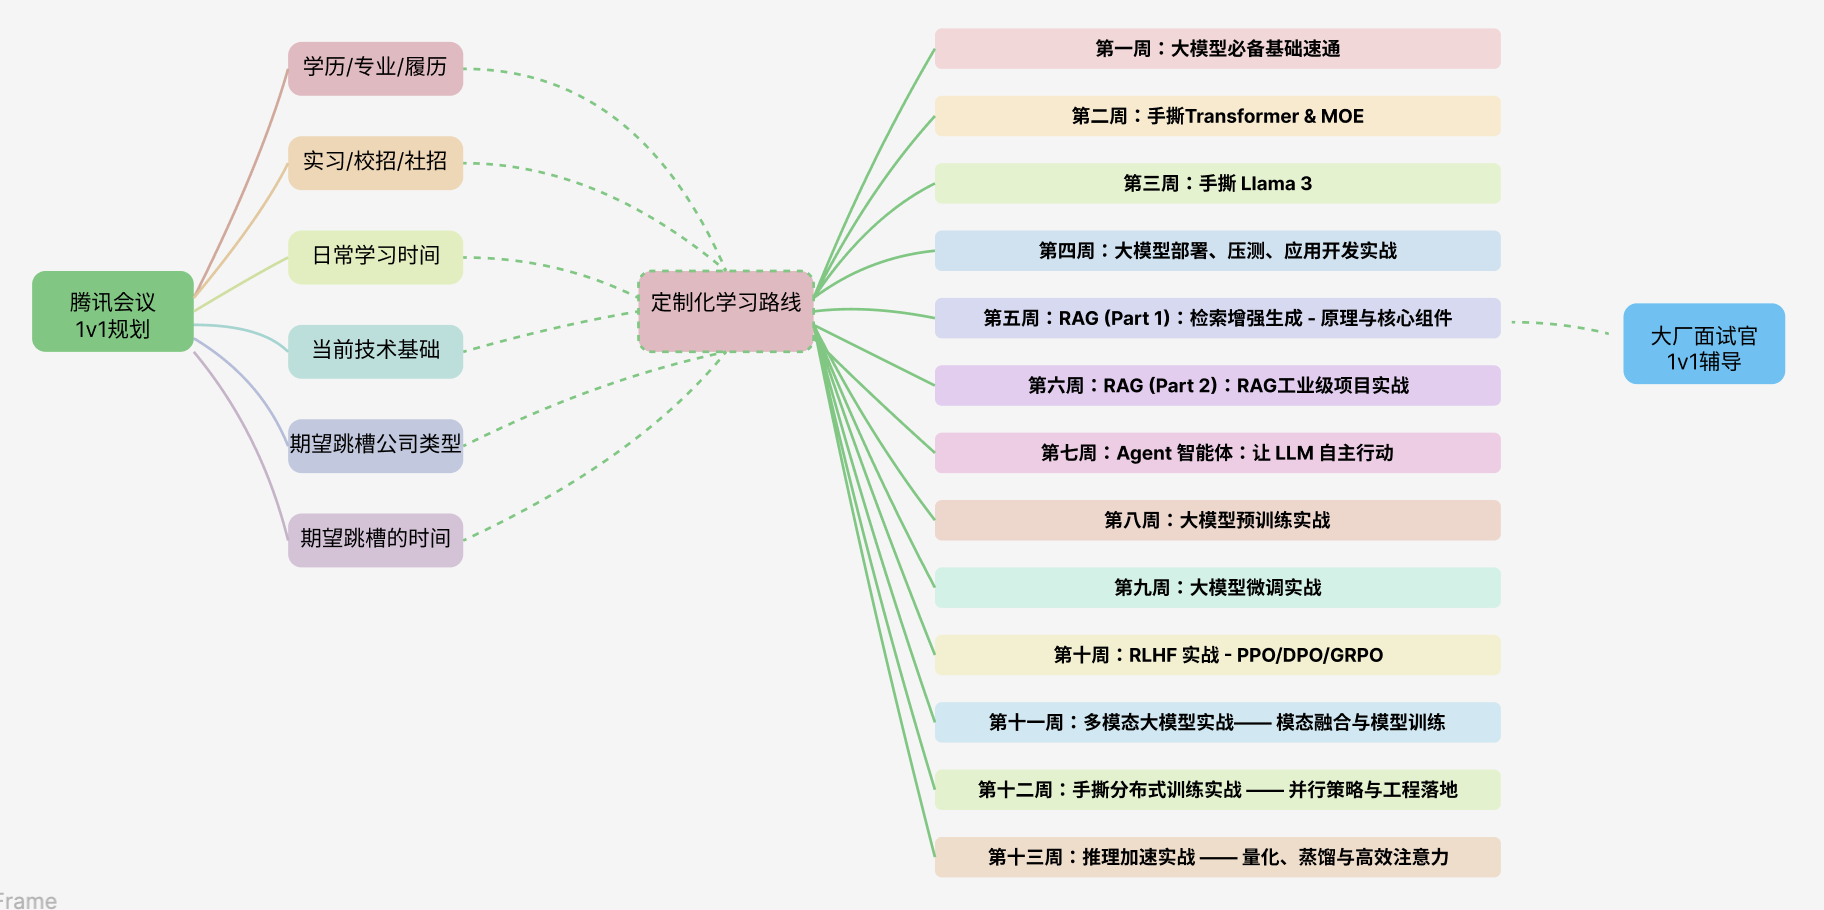

<img src="2.svg" width="1100"/>

# 1.神经网络是什么

<img src="3.svg" width="1100"/>

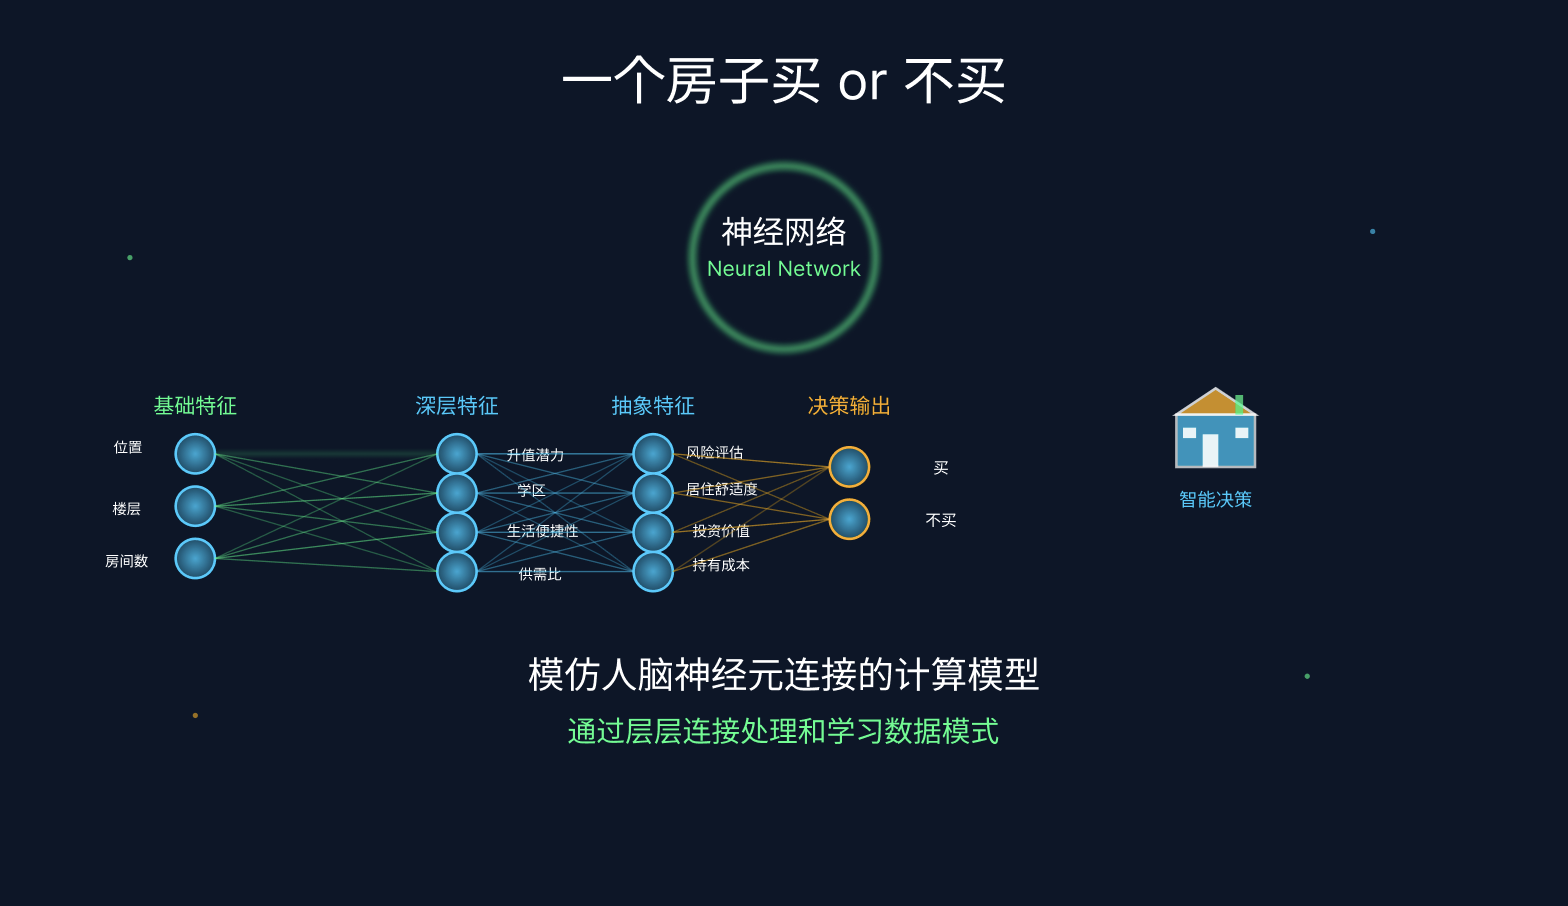

<img src="4.svg" width="1100"/>

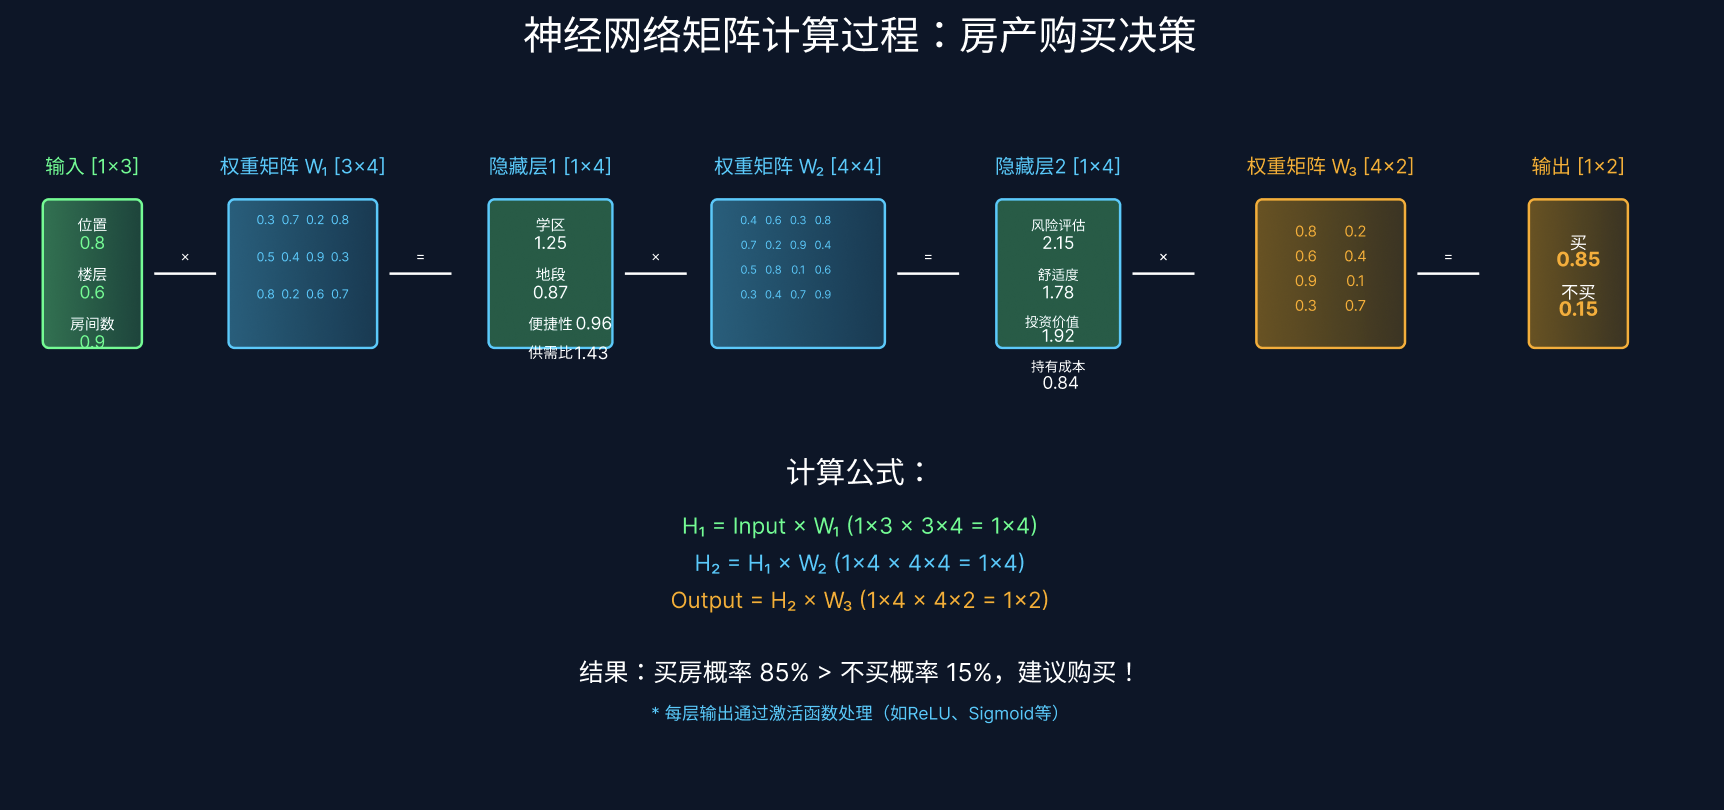

# 损失函数

### 1.1. 把神经网络想成一群“经验丰富的助理”

* **每个“助理”就是一个“神经元”**。
* 他们被排成几排：第一排专门接收原始信息（房子的面积、房龄、位置、周边学校、挂牌价……），最后一排给出结论（“值”或“不值”）。中间几排则在不断“咀嚼”、组合这些信息。

### 1.2. 助理们如何“看房”？

1. **收集信息**
   第一排助理各拿到一样原始数据：

   * A 助理拿房子的面积
   * B 助理拿房龄
   * C 助理拿距离地铁的距离
   * ……

2. **给出个人打分**
   每个助理心里都有一套“私房权重”（例如他觉得面积重要性 0.8，房龄重要性 0.4）。他们把手里那条信息乘上权重，得出一个“小分”。

3. **传给下一排**
   第二排助理收到前面所有“小分”后，再根据自己的一套权重加权平均；如果分数高到一定阈值就“点亮”（这一步就叫**激活函数**），否则保持沉默。

   > 点亮 = “这房子在面积+房龄维度看起来不错！”
   > 沉默 = “没啥亮点，先略过。”

4. **重复几轮**
   层层传递、不断组合后，最后一排只留下一个数字，比如 **0.93**——可以把它理解为“93% 可能值得买”。

### 1.3. 他们的“经验”从哪来？

* **训练数据**：过去大量真实案例，比如 10 万套房子的实际成交价、居住满意度等。
* **学习过程**：一开始助理们的权重是随机的，预测肯定很离谱。**我们把预测结果和真实结果做比较，算出“差错”（损失函数），再用“反向传播”算法告诉每位助理该把权重调高还是调低——就像老板复盘后告诉员工“面积太重要了，你得更关注”。**
* **迭代**：在全部历史案例上来回练习几轮，误差越来越小，权重逐渐稳定，就形成了有经验的“看房团队”。

### 1.4. 新房子来了怎么用？

把这套房子的所有特征一股脑儿喂给第一排助理，让他们按学好的权重一路运算。几毫秒后，你就拿到了 0–1 之间的2个概率分数，分别是买和不买的，和为1，买的概率：

* **≥ 0.8**　→　值！
* **0.5 – 0.8**　→　再谈谈价。
* **< 0.5**　→　慎重。

### 1.5. 为什么不用“单条公式”而要这么麻烦？

* **自动提炼复杂规律**：比如“面积大但学区一般 + 房龄新 + 小区绿化好”这种多条件组合，很难手写公式，但神经网络能自己学到。
* **可扩展**：想加“未来地铁规划”“区域租售比”之类新特征，只要把数据喂进去就行，不必重新写规则。
* **非线性**：房价不一定随面积线性增长，神经网络的层层激活可以捕捉这种弯弯曲曲的关系。

---

**一句话总结**

> 神经网络就是一大群会自我纠正权重的“数字助理”。他们靠大量历史案例磨炼本领，最后能把复杂的房屋信息转成一个简单概率，告诉你这套房子“值不值得买”。


### 1.6. 梯度更新的过程？

下面用你图里的数字（买／不买＝0.85／0.15）做一次 **“手算版”反向传播**，让每一步都能对上矩阵的形状，帮你彻底看懂链式法则在多层网络里的传递过程。

---

##### 0　前向传播回顾

> **X (1 × 3)** → **W₁ (3 × 4)** → **H₁ (1 × 4)** → **W₂ (4 × 4)** → **H₂ (1 × 4)** → **W₃ (4 × 2)** → **Z₃ / ŷ (1 × 2)**
> （激活用 ReLU，输出用 Softmax）

| 名称                    | 具体数值（取自图片，4 位小数）                            |
| --------------------- | ------------------------------------------- |
| **X**                 | `[0.80, 0.60, 0.90]`                        |
| **W₁**                | ![3×4矩阵](…)                                 |
| **H₁**                | `[1.25, 0.87, 0.96, 1.43]`                  |
| **W₂**                | ![4×4矩阵](…)                                 |
| **H₂**                | `[2.15, 1.78, 1.92, 0.84]`                  |
| **W₃**                | `[[0.8,0.2],[0.6,0.4],[0.9,0.1],[0.3,0.7]]` |
| **Softmax( Z₃ ) = ŷ** | `[0.85, 0.15]`                              |

假设这条样本的真实标签 **y = \[1, 0]**（客户最终“买房”）。
损失函数用 **交叉熵**

$$
L = -\sum_{i} y_i\log \hat y_i
$$

---

##### 1　输出层梯度

对于「Softmax + Cross-Entropy」的组合，梯度非常简洁：

$$
\delta_3 = \nabla_{Z_3}L = \hat y - y = [0.85-1,\;0.15-0] = [-0.15,\;0.15]
$$

形状 **(1 × 2)** ，正好与 Z₃ 一致。

###### 梯度 w\.r.t W₃

$$
\nabla_{W_3}L = H_2^{\mathsf T}\,\delta_3
$$



---

##### 2　隐藏层 2（H₂）梯度

先把误差传回到 H₂：

$$
\delta_2 = \delta_3\,W_3^{\mathsf T}\quad (1\times2 \times 2\times4 \Rightarrow 1\times4)
= [-0.15,\;0.15]
\begin{bmatrix}
0.8 & 0.6 & 0.9 & 0.3\\
0.2 & 0.4 & 0.1 & 0.7
\end{bmatrix}
= [-0.09,\,-0.03,\,-0.12,\;0.06]
$$

ReLU 的梯度：

$$
f'(z)=
\begin{cases}
1,&z>0\\
0,&z\le0
\end{cases}
$$

H₂ 四个分量均 > 0，所以不用截断（仍然留作 δ₂）。

###### 梯度 w\.r.t W₂

$$
\nabla_{W_2}L = H_1^{\mathsf T}\,\delta_2
$$

$$
\begin{bmatrix}
1.25\\0.87\\0.96\\1.43
\end{bmatrix}
\!
\begin{bmatrix}
-0.09 & -0.03 & -0.12 & 0.06
\end{bmatrix}
=
\begin{bmatrix}
-0.1125 & -0.0375 & -0.1500 & 0.0750\\
-0.0783 & -0.0261 & -0.1044 & 0.0522\\
-0.0864 & -0.0288 & -0.1152 & 0.0576\\
-0.1287 & -0.0429 & -0.1716 & 0.0858
\end{bmatrix}
$$

---

##### 3　隐藏层 1（H₁）梯度

$$
\delta_1 = \delta_2\,W_2^{\mathsf T}\quad (1\times4 \times 4\times4)
= [-0.042,\,-0.153,\,-0.045,\,-0.069]
$$

H₁ 仍是 ReLU 正区间 → 梯度保留。

###### 梯度 w\.r.t W₁

$$
\nabla_{W_1}L = X^{\mathsf T}\,\delta_1
$$

$$
\begin{bmatrix}
0.80\\0.60\\0.90
\end{bmatrix}
\!
\begin{bmatrix}
-0.042 & -0.153 & -0.045 & -0.069
\end{bmatrix}
=
\begin{bmatrix}
-0.0336 & -0.1224 & -0.0360 & -0.0552\\
-0.0252 & -0.0918 & -0.0270 & -0.0414\\
-0.0378 & -0.1377 & -0.0405 & -0.0621
\end{bmatrix}
$$

---

##### 4　权重更新（SGD 举例）

给定学习率 η，例如 η = 0.01：

$$
W_i\; \leftarrow\; W_i - \eta\,\nabla_{W_i}L
$$

对三层权重分别执行即可 —— 这就是一次完整的 **反向传播 + 梯度下降**。

---

###### 重点小结

| 步骤             | 链式法则公式                 | 形状    |
| -------------- | ---------------------- | ----- |
| 输出层            | `δ₃ = ŷ − y`           | 1 × 2 |
| `∇W₃ = H₂ᵀ δ₃` | 4 × 2                  |       |
| 隐藏层 2          | `δ₂ = δ₃ W₃ᵀ ⊙ f′(Z₂)` | 1 × 4 |
| `∇W₂ = H₁ᵀ δ₂` | 4 × 4                  |       |
| 隐藏层 1          | `δ₁ = δ₂ W₂ᵀ ⊙ f′(Z₁)` | 1 × 4 |
| `∇W₁ = Xᵀ δ₁`  | 3 × 4                  |       |

> **⊙** 表示按元素乘（Hadamard），只在激活函数需要时才出现。
> 如果网络还有 bias，则各层 bias 的梯度就是对应 δ 向量本身的行（或列）求和。

掌握了「误差向量 δ 从后往前传，权重梯度 = 前一层输出ᵀ × δ」这两条规则，无论层数、激活或损失怎么换，反向传播都可以机械地推出来。希望这个具体数字的推导能帮你把抽象公式和直观矩阵运算彻底连起来！


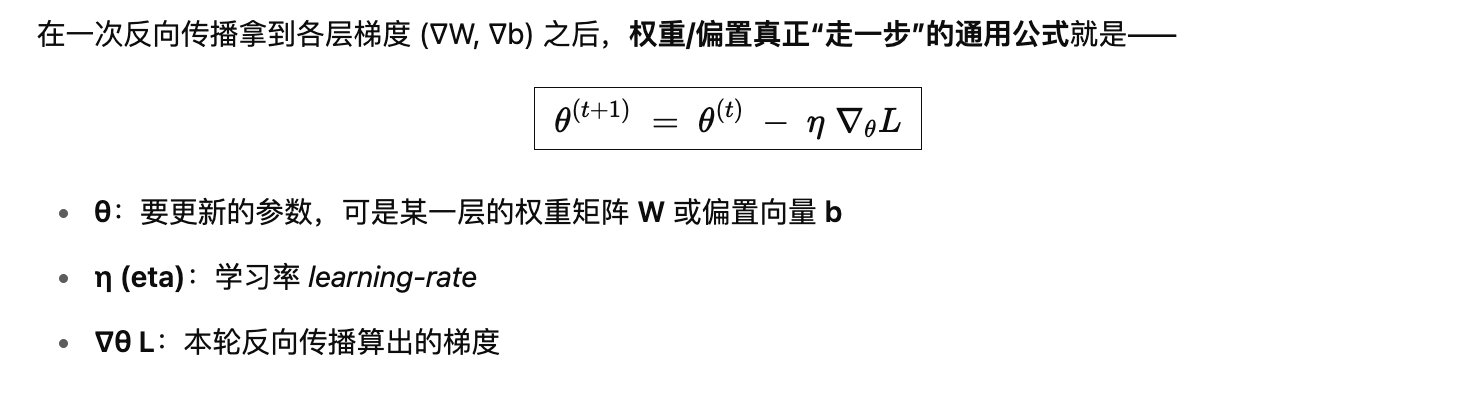

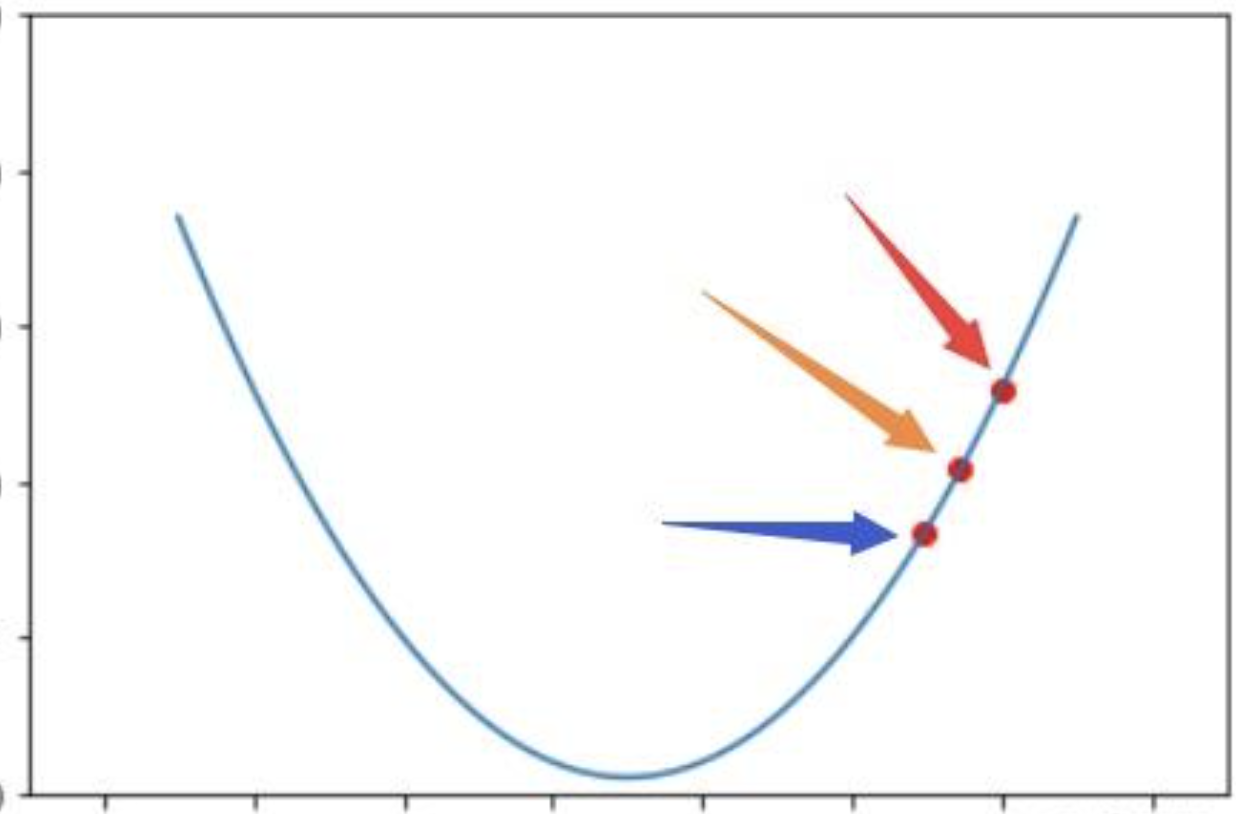

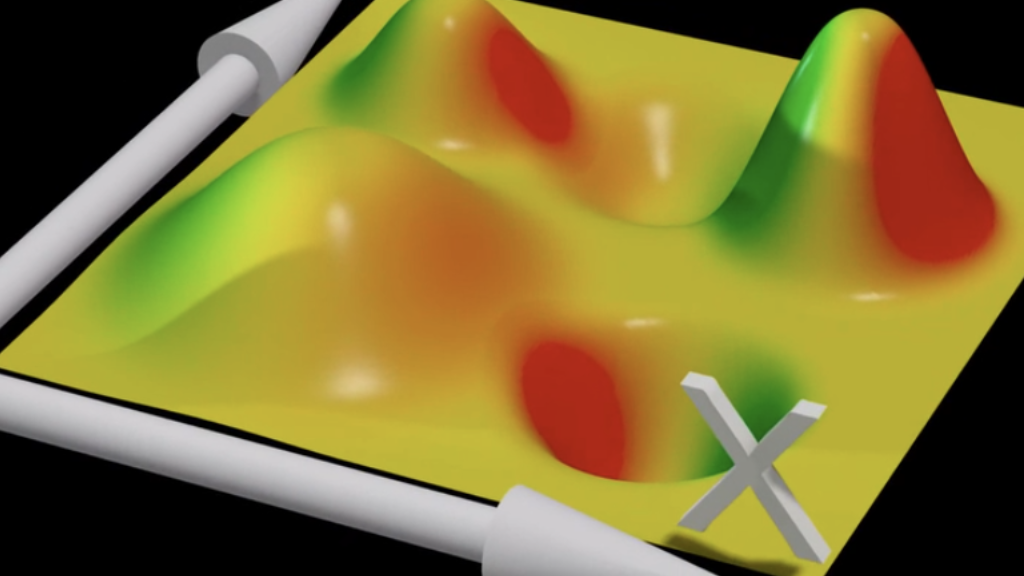

# 2、认识transformer

## 2.1 transformer（LLM）在干嘛

**transformer就是一个函数，输入一个序列，预测下一个token是什么**

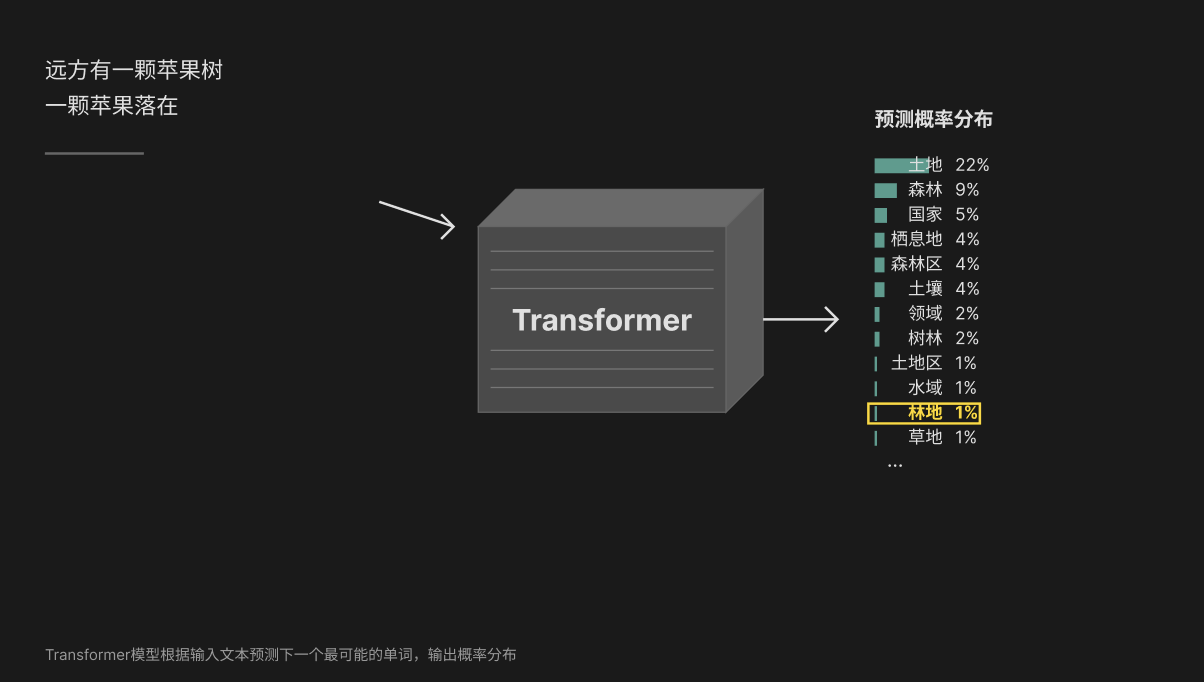

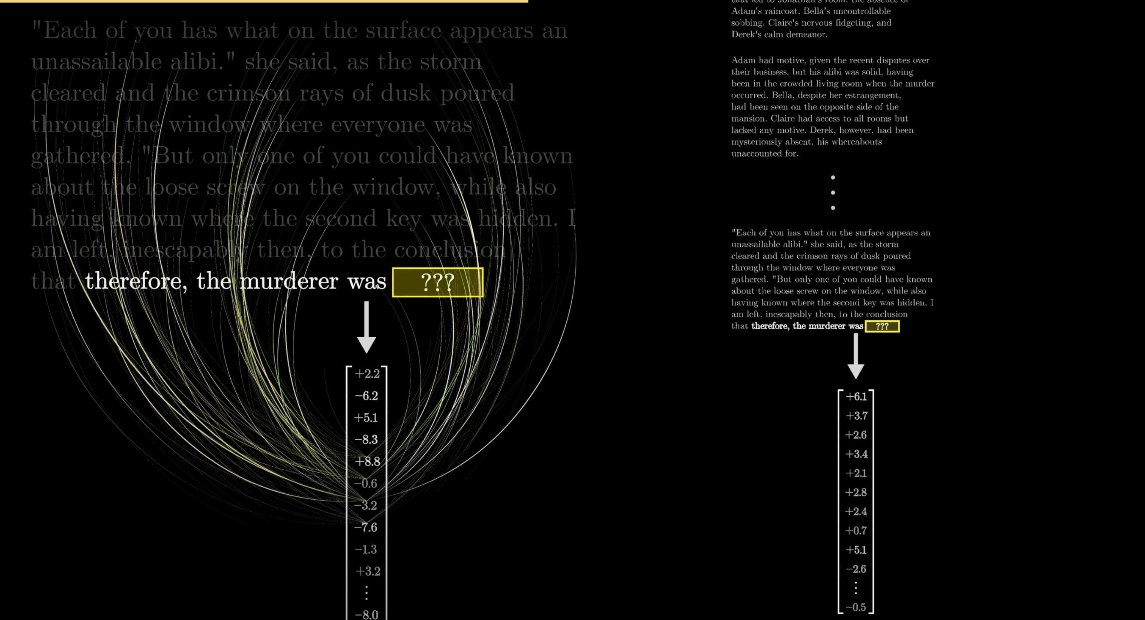

## 先看一看RNN和LSTM

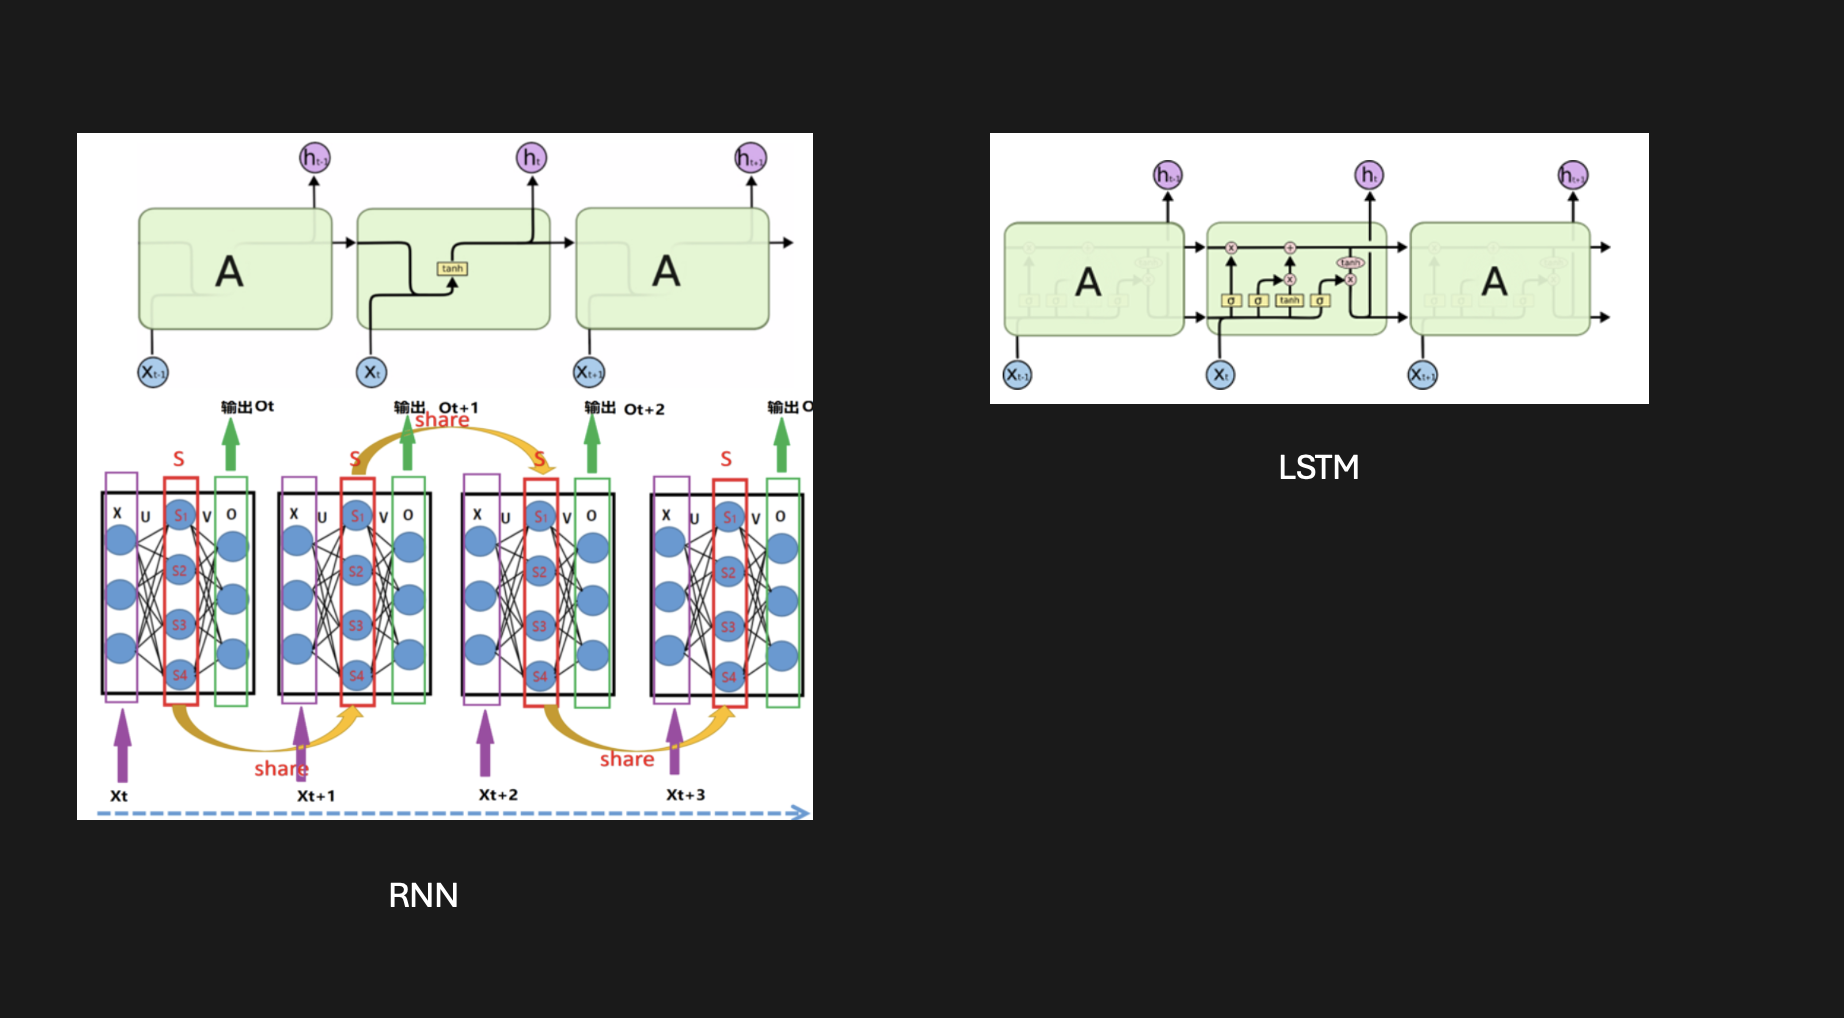

- 串行计算效率低
- 只有一层，无法关注深层次的语义特征
- 长距离信息丢失

## 那么为什么还需要transformer呢

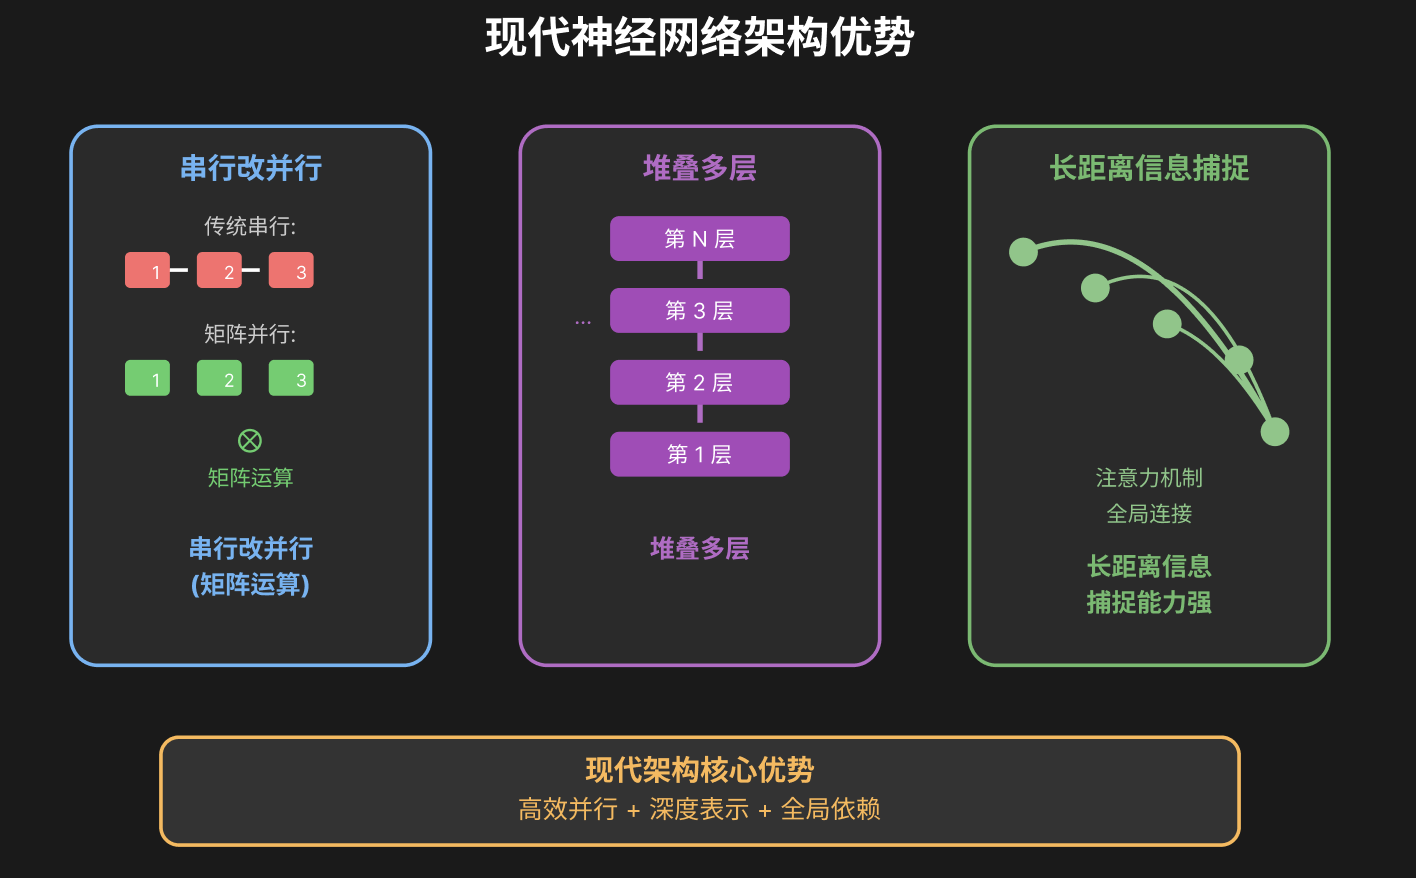

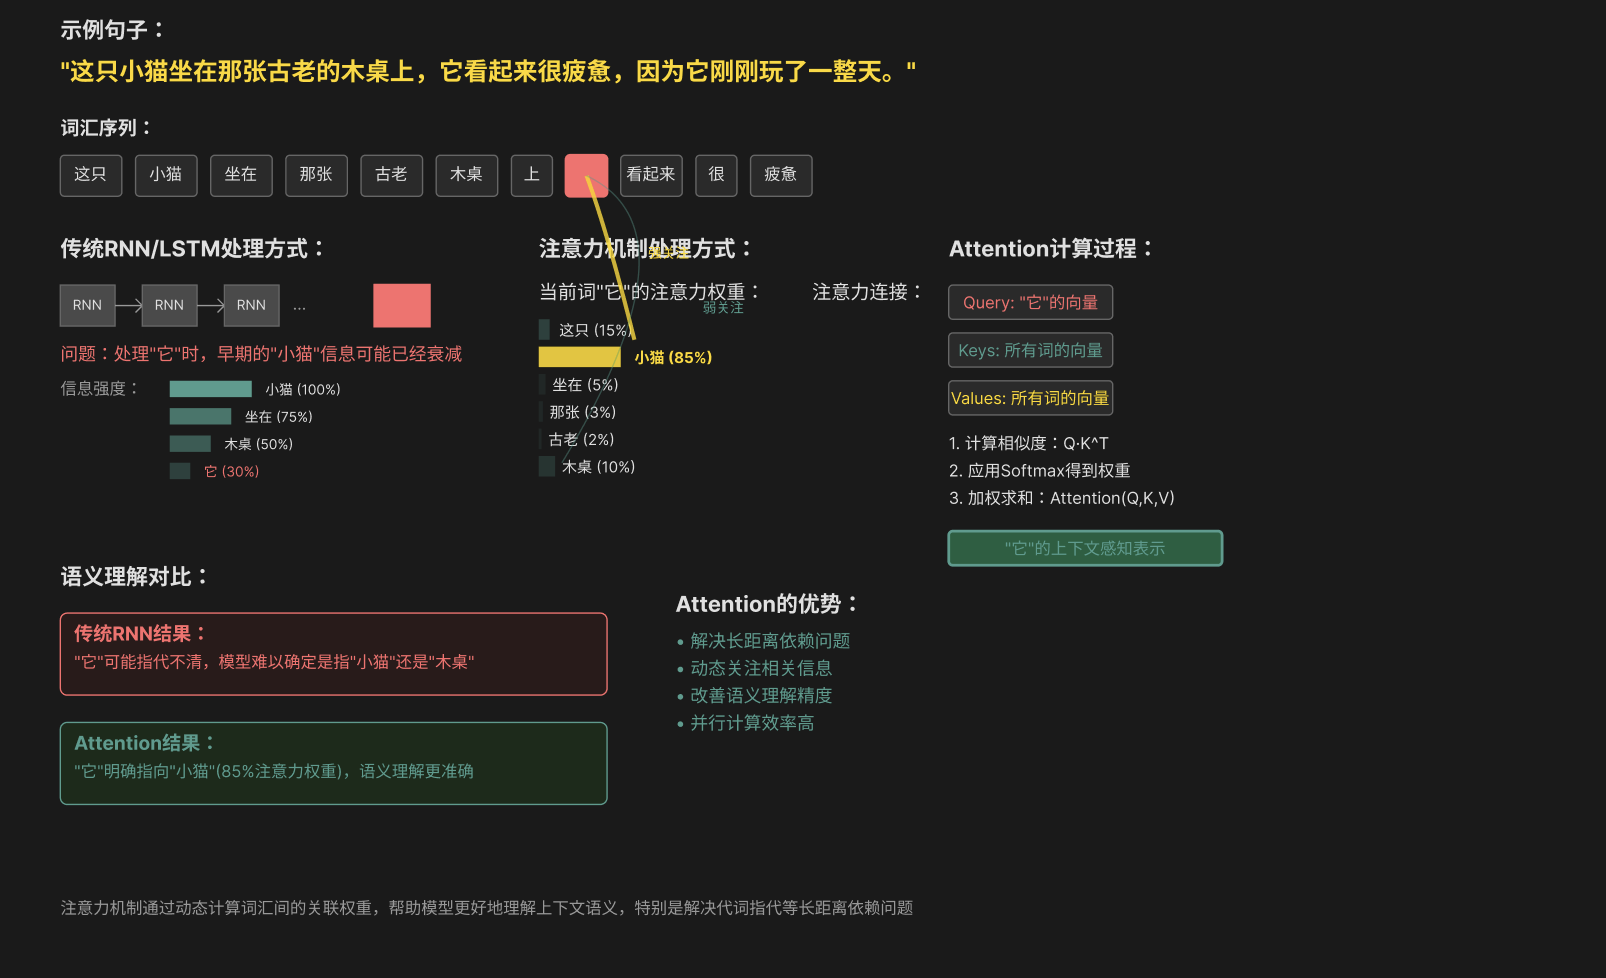

## 2.2 transformer由哪些模块组成

### Attention is all you need

https://arxiv.org/pdf/1706.03762

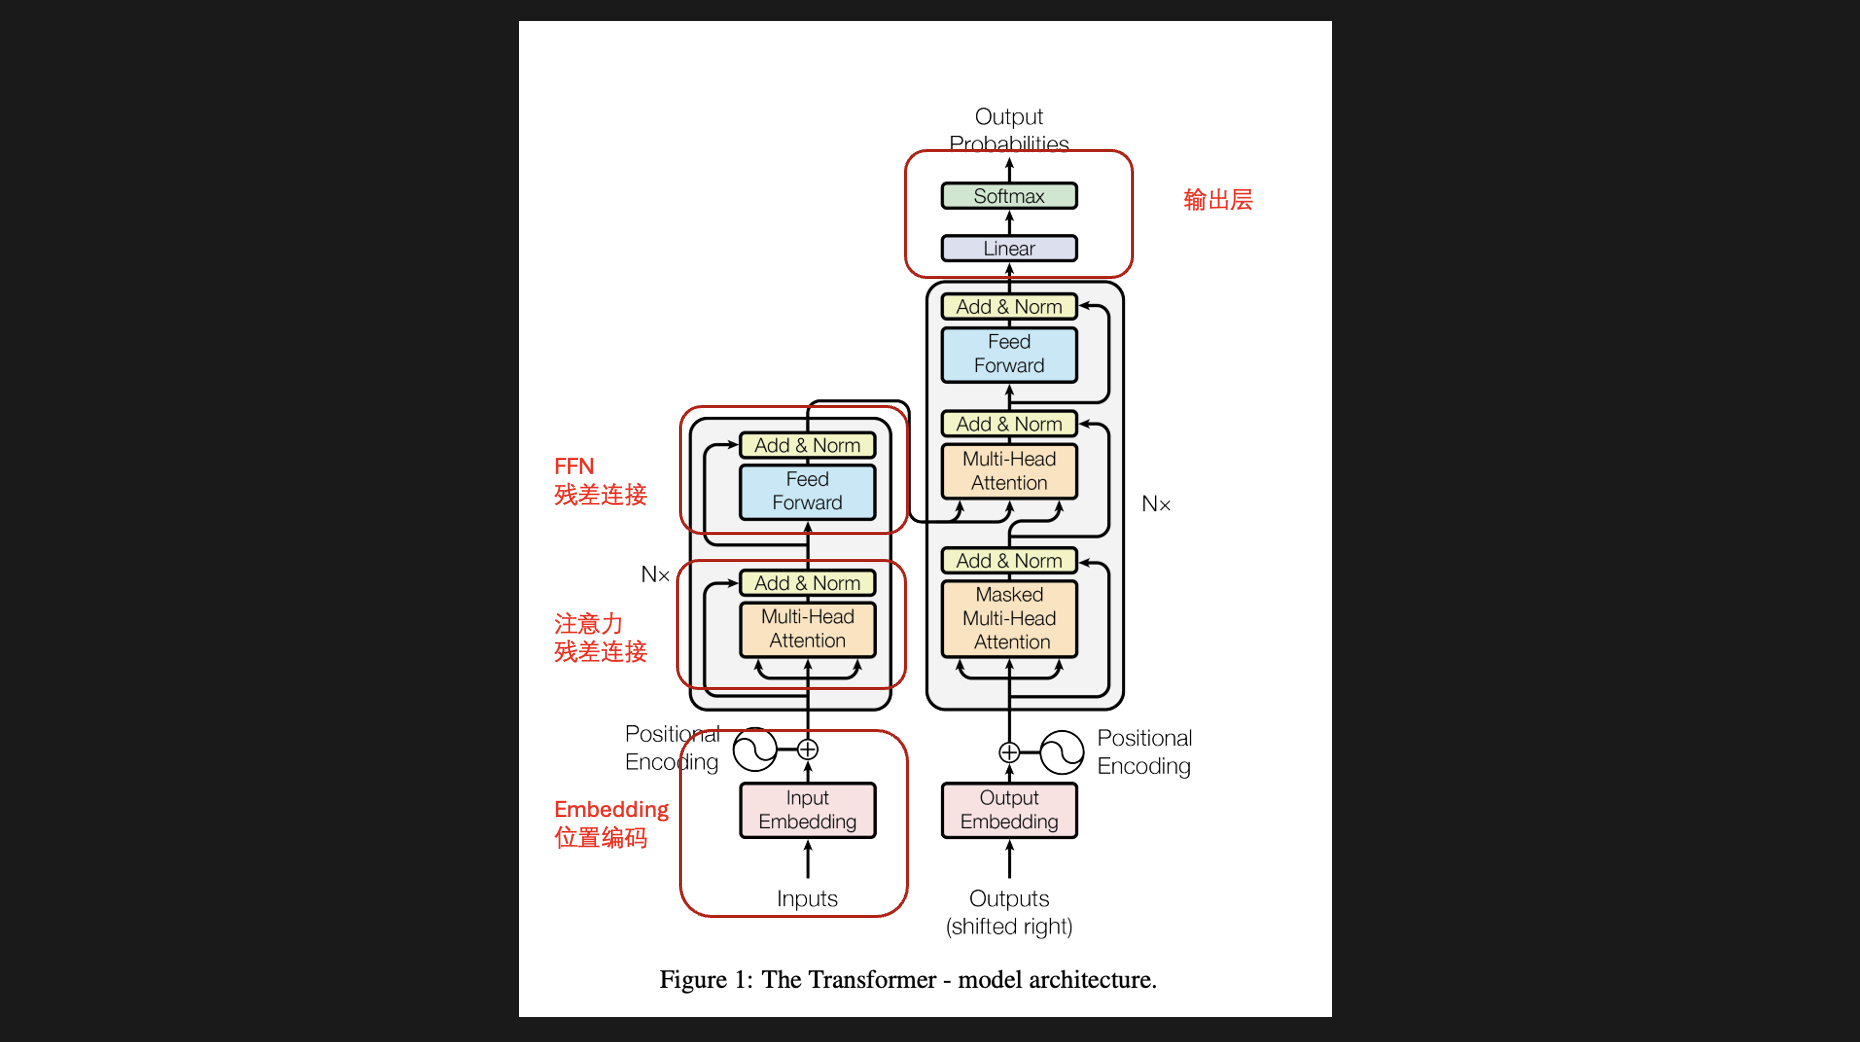

### 2.2.1 embedding和位置编码

#### 先理解词向量

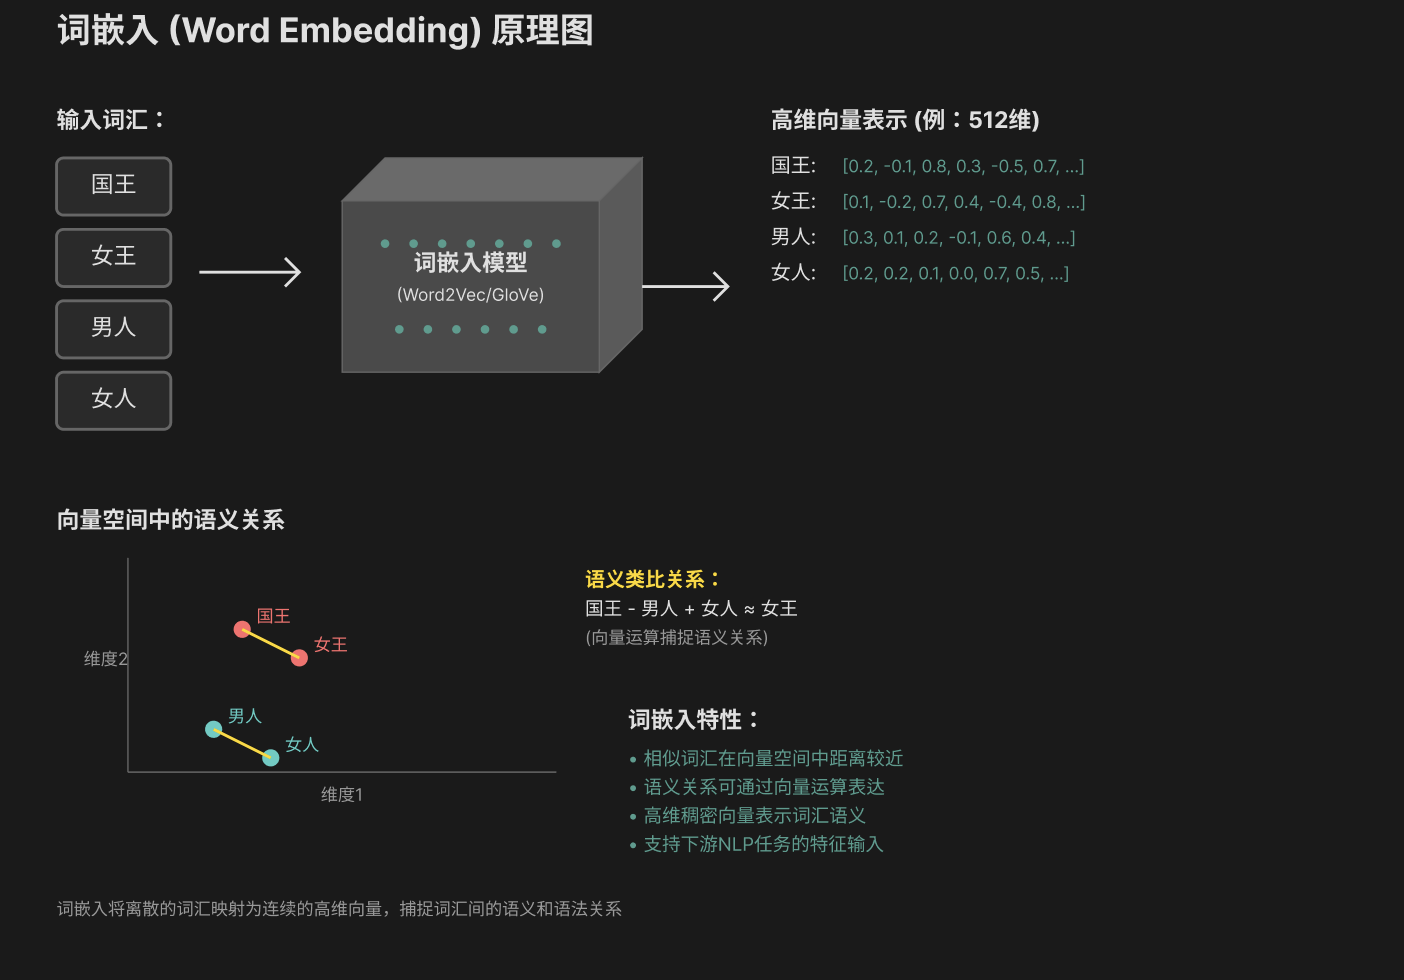

In [ ]:
[0,1,0,0]=国王=1
[1,0,0,0]=女王=2
[0,0,1,0]=男人=3
[0,0,0,1]=女人=4

**稠密词向量（dense word embeddings）是什么？**
稠密词向量把每个词映射成一个低维、连续实数向量（几十到几百维常见），这些向量通过训练让相似词在向量空间里距离更近、方向更相似。常见训练方法有 Word2Vec、GloVe、fastText，以及现代 Transformer 模型里的词嵌入层。

---

### 与 one-hot 编码的对比

|           | one-hot 向量       | 稠密词向量            |
| --------- | ---------------- | ---------------- |
| **维度**    | 词表大小（动辄 10⁴–10⁶） | 50–4096 左右       |
| **稀疏/稠密** | 极度稀疏，除了 1 其余全 0  | 完全稠密             |
| **存储/计算** | 内存占用大，矩阵乘法浪费     | 占用小，GPU/CPU 乘法高效 |
| **语义关系**  | 彼此正交，无法度量相似度     | 余弦距离可衡量同义/相关度    |
| **泛化能力**  | 只有“是否相同”信息       | 可以“以词找词”，支持类比、聚类 |
| **训练方式**  | 无需训练，直接 one-hot  | 需要通过无监督或下游任务学习   |

> **优势总结**：稠密词向量把高维稀疏空间压缩成低维连续空间，保留了词义邻近性；因此在计算复杂度、记忆效率、模型可学习性和语义泛化上都优于 one-hot。

---

### 与“ID 编码”的对比

有时我们直接把词映射成整数 ID，再喂入神经网络查词嵌入表。若**只用 ID 而不学习 embedding**（例如直接输入到可解释模型或规则系统），问题与 one-hot 类似：

* **无法表达词间相似度**：ID 仅是索引，2 与 5 的数字大小无任何含义。
* **维度问题**：需要再转成 one-hot 才可与线性模型结合，否则模型无法区分词。
* **离散特征**：模型对未见词 ID 处理困难，泛化差。

而**ID + 嵌入表**本质上就等价于稠密词向量：ID 用来查表，获得 dense embedding，再参与后续计算。所以优势依旧是语义压缩与稠密计算。

---

### 稠密词向量为下游任务带来的具体好处

1. **减少参数量**

   * 文本分类里把词嵌入层 + 轻量网络，就能替代巨大的 one-hot 线性层。
2. **更快收敛**

   * 低维连续特征让梯度传播稳定；模型更容易学到有用模式。
3. **跨任务/跨域迁移**

   * 预训练的泛用词向量可微调到情感分析、命名实体识别等多种任务。
4. **处理长尾与未登录词**

   * 形态学敏感的嵌入（fastText 子词、BPE token）能给罕见词合理向量，不会像 one-hot 那样完全陌生。
5. **支持向量运算与可视化**

   * 可做“king − man + woman ≈ queen”类比；用 t-SNE/U-MAP 直观展示语义簇。


## 开始完整的transformer过程

In [ ]:
what's that
what | 's | that

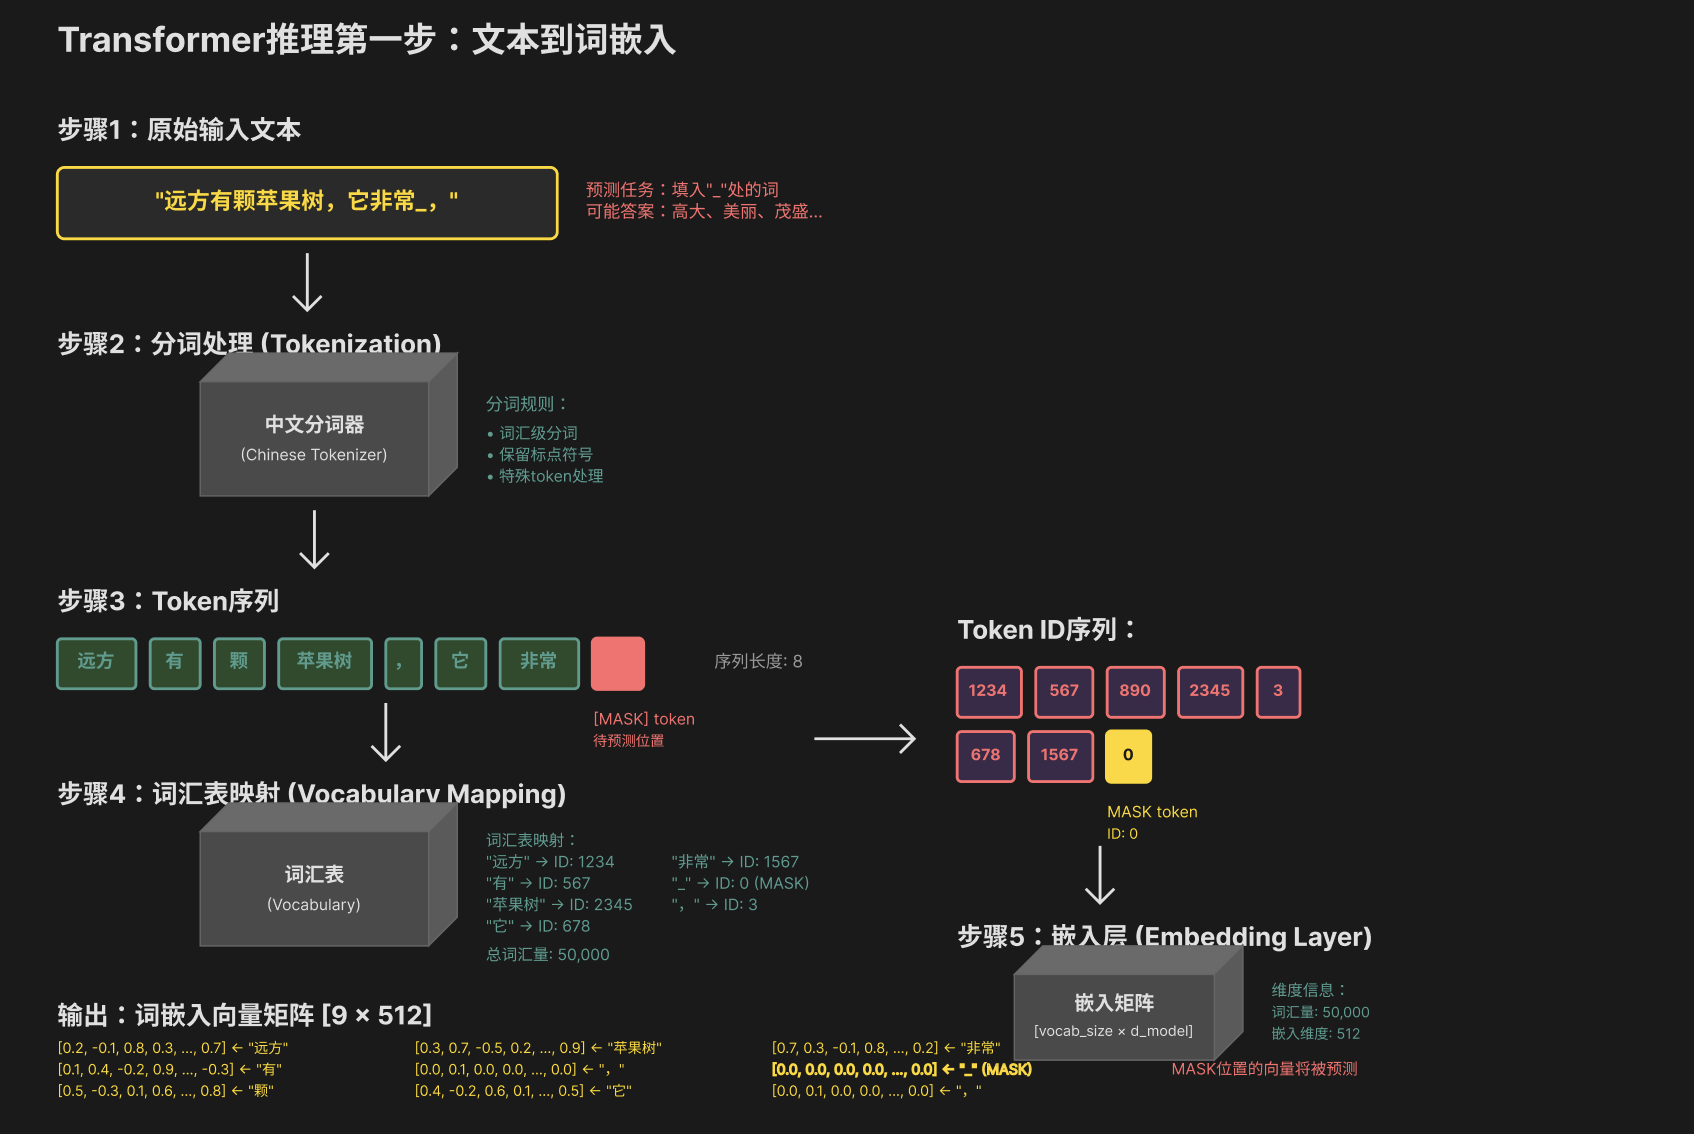

## 大家思考一个问题，我打你，你打我，这两个“我”的embedding应该一样吗

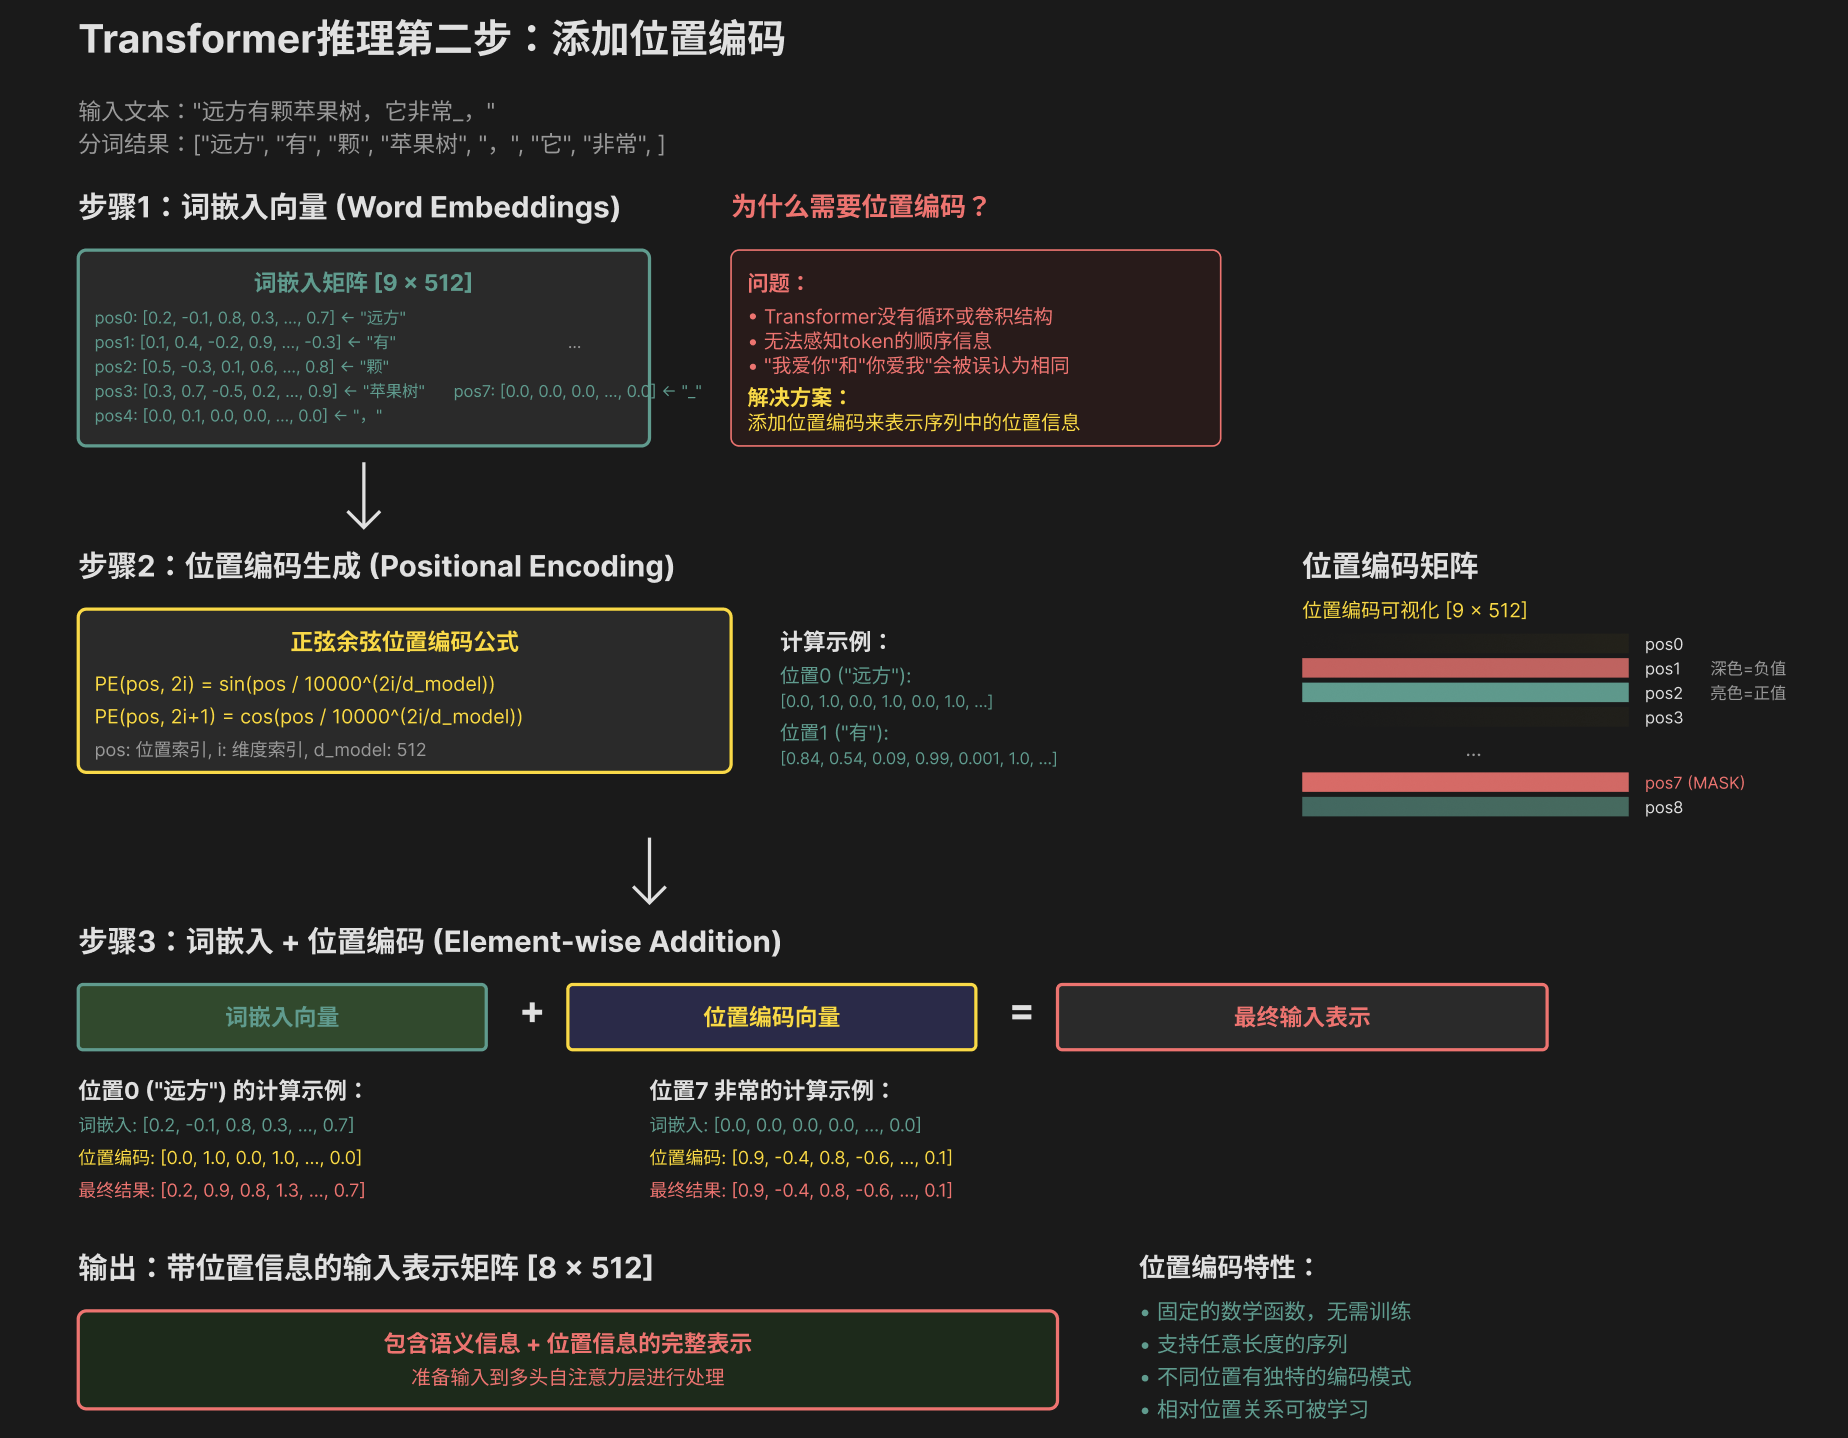

### 2.2.2 Attention机制 & LayerNorm & 残差连接

我喜欢吃**苹果**
我喜欢用**苹果**电脑

## Attention机制：考虑别的token对当前token在语义空间中的影响，让它能够非常准确的用高纬度的向量表达语义特征

In [ ]:
[1,2,3]
[4,5,6]

[1,2,3,4,5,6]

W_o-512*512
- 8*512

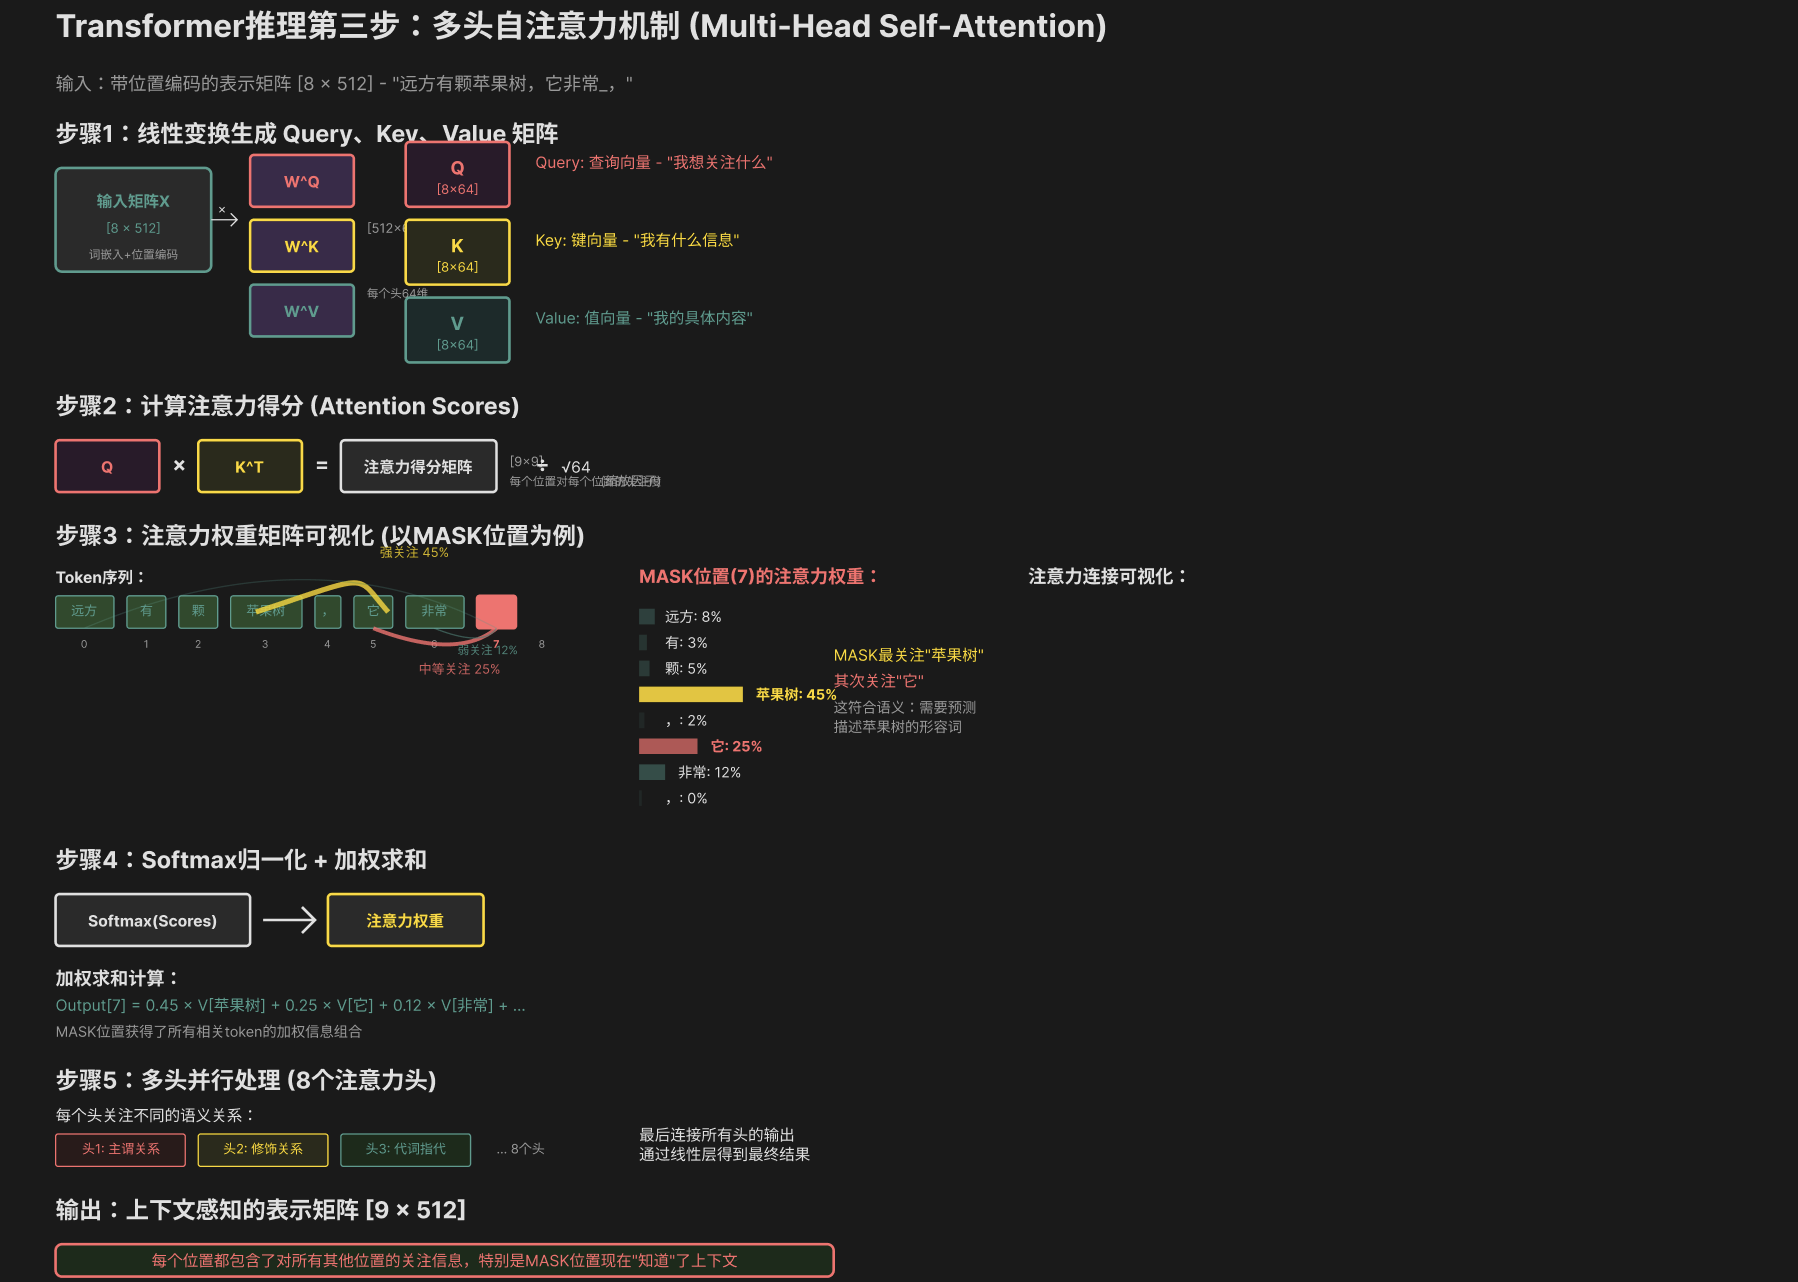

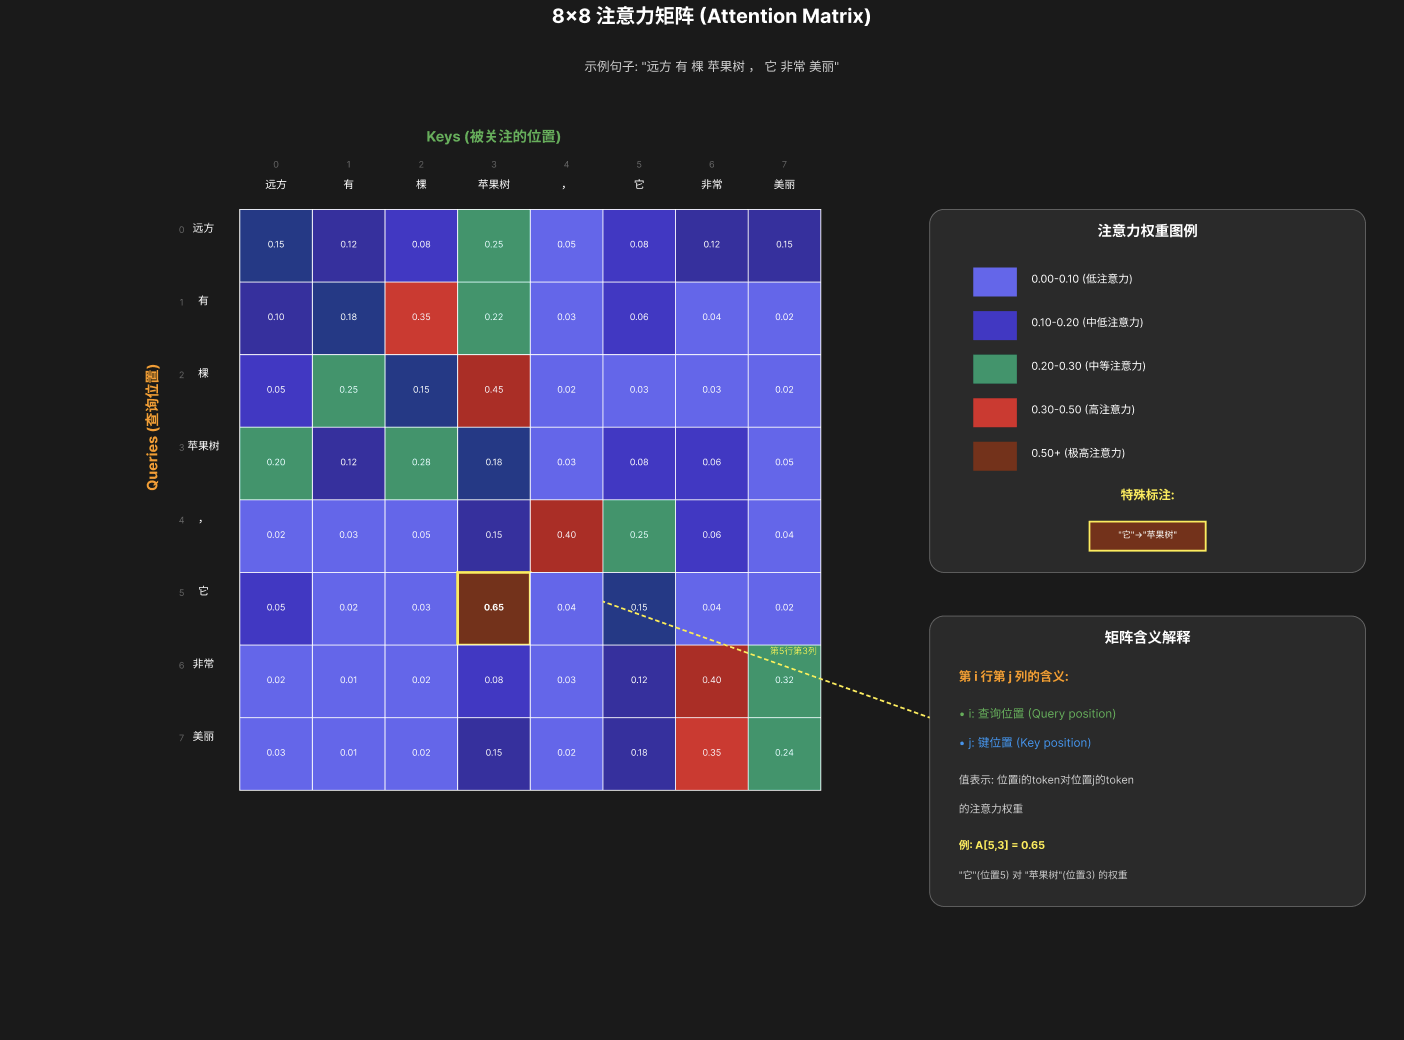

## 8×8注意力矩阵详解

### **第i行第j列的含义**

在注意力矩阵中，**第i行第j列**的数值表示：
- **位置i的token（作为Query）对位置j的token（作为Key）的注意力权重**

### **具体解释**

| 维度 | 含义 | 示例 |
|------|------|------|
| **行索引 i** | 查询位置(Query) | 第5行 = "它"作为查询 |
| **列索引 j** | 键位置(Key) | 第3列 = "苹果树"作为键 |
| **数值 A[i,j]** | 注意力权重 | A[5,3] = 0.65 |

### **重要特性**

1. **行归一化**：每行所有元素之和为1
   - Σⱼ A[i,j] = 1 (对所有i)

2. **非对称性**：A[i,j] ≠ A[j,i]
   - "它"关注"苹果树" ≠ "苹果树"关注"它"

3. **语义相关性**：权重反映语义关联强度
   - 高权重：语义相关度高
   - 低权重：语义相关度低

### **矩阵中的关键模式**

从图中可以观察到：

1. **指代消解**：A[5,3] = 0.65 ("它"→"苹果树")
2. **修饰关系**：A[2,3] = 0.45 ("棵"→"苹果树") 
3. **语序依赖**：相邻词汇有较高注意力权重
4. **语法结构**：标点符号连接前后语义块

这就是注意力机制如何捕捉和建模词汇间复杂语义关系的核心原理！


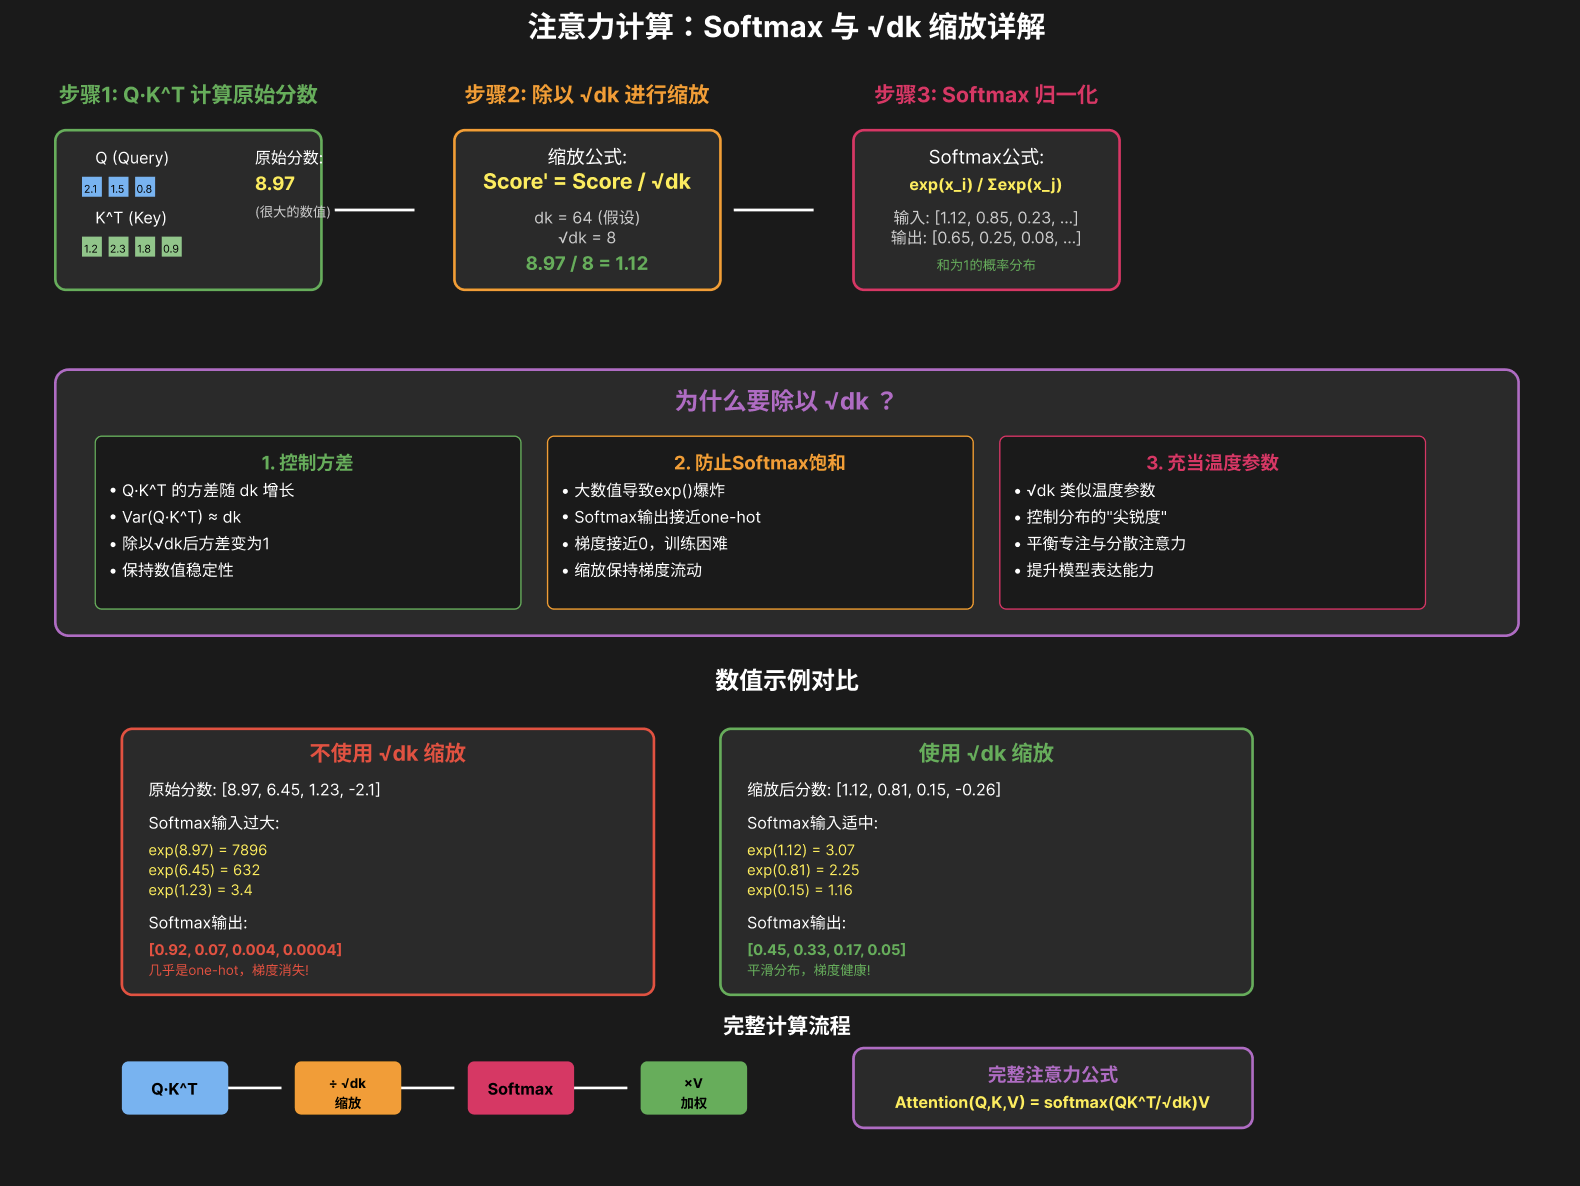

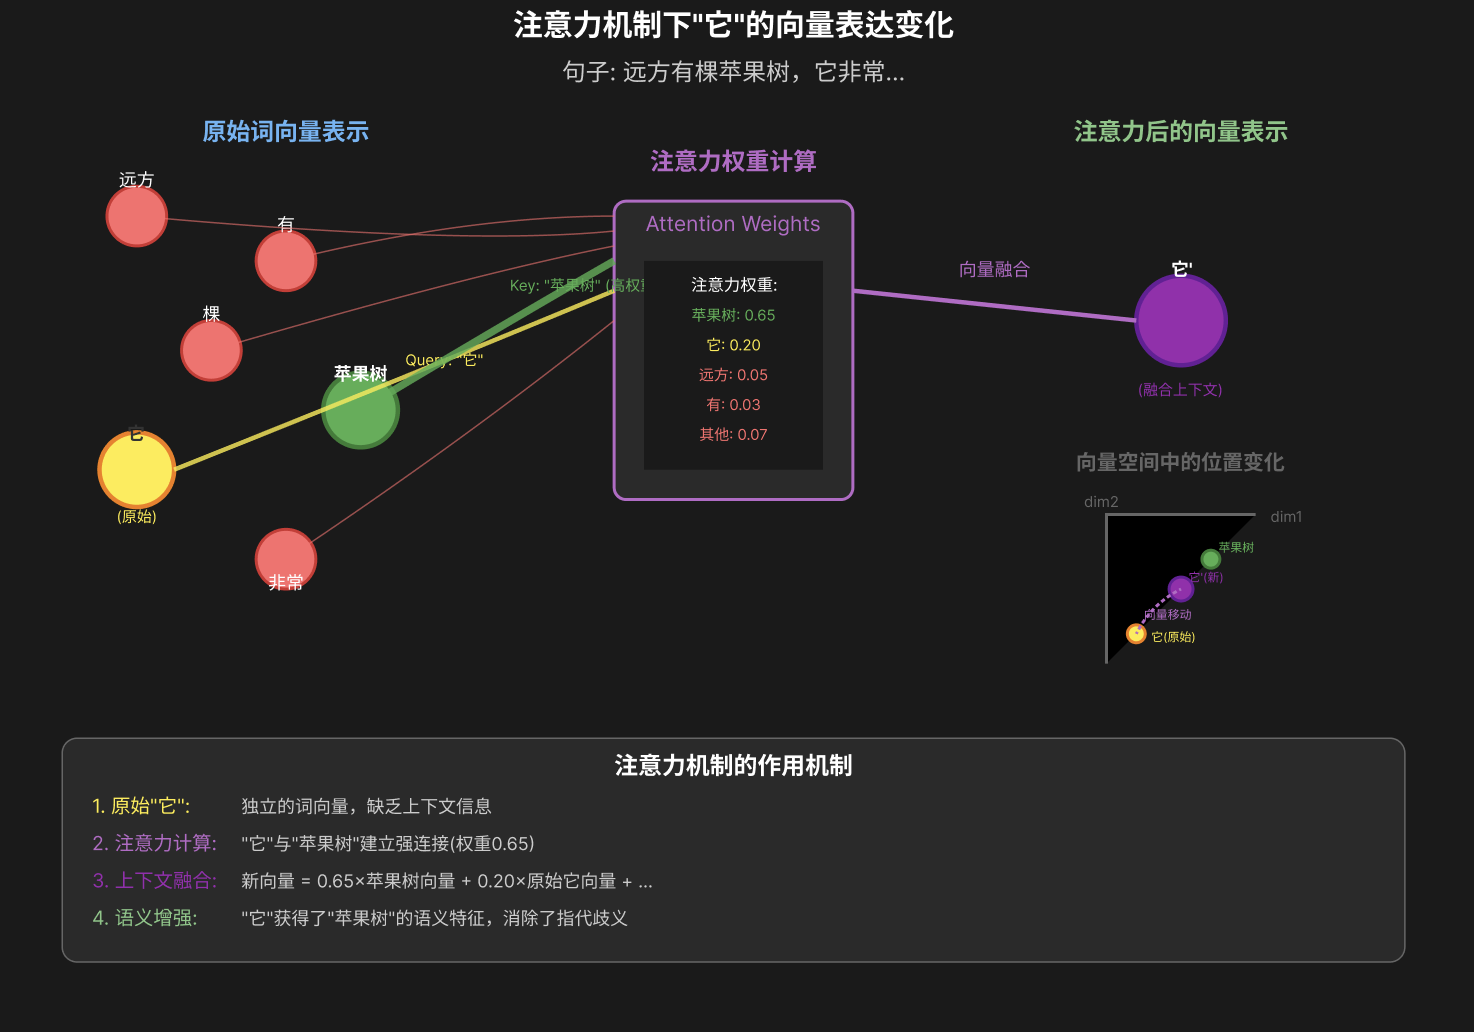

## 这里解决了串行、长距离位置捕捉的问题

### LayerNorm

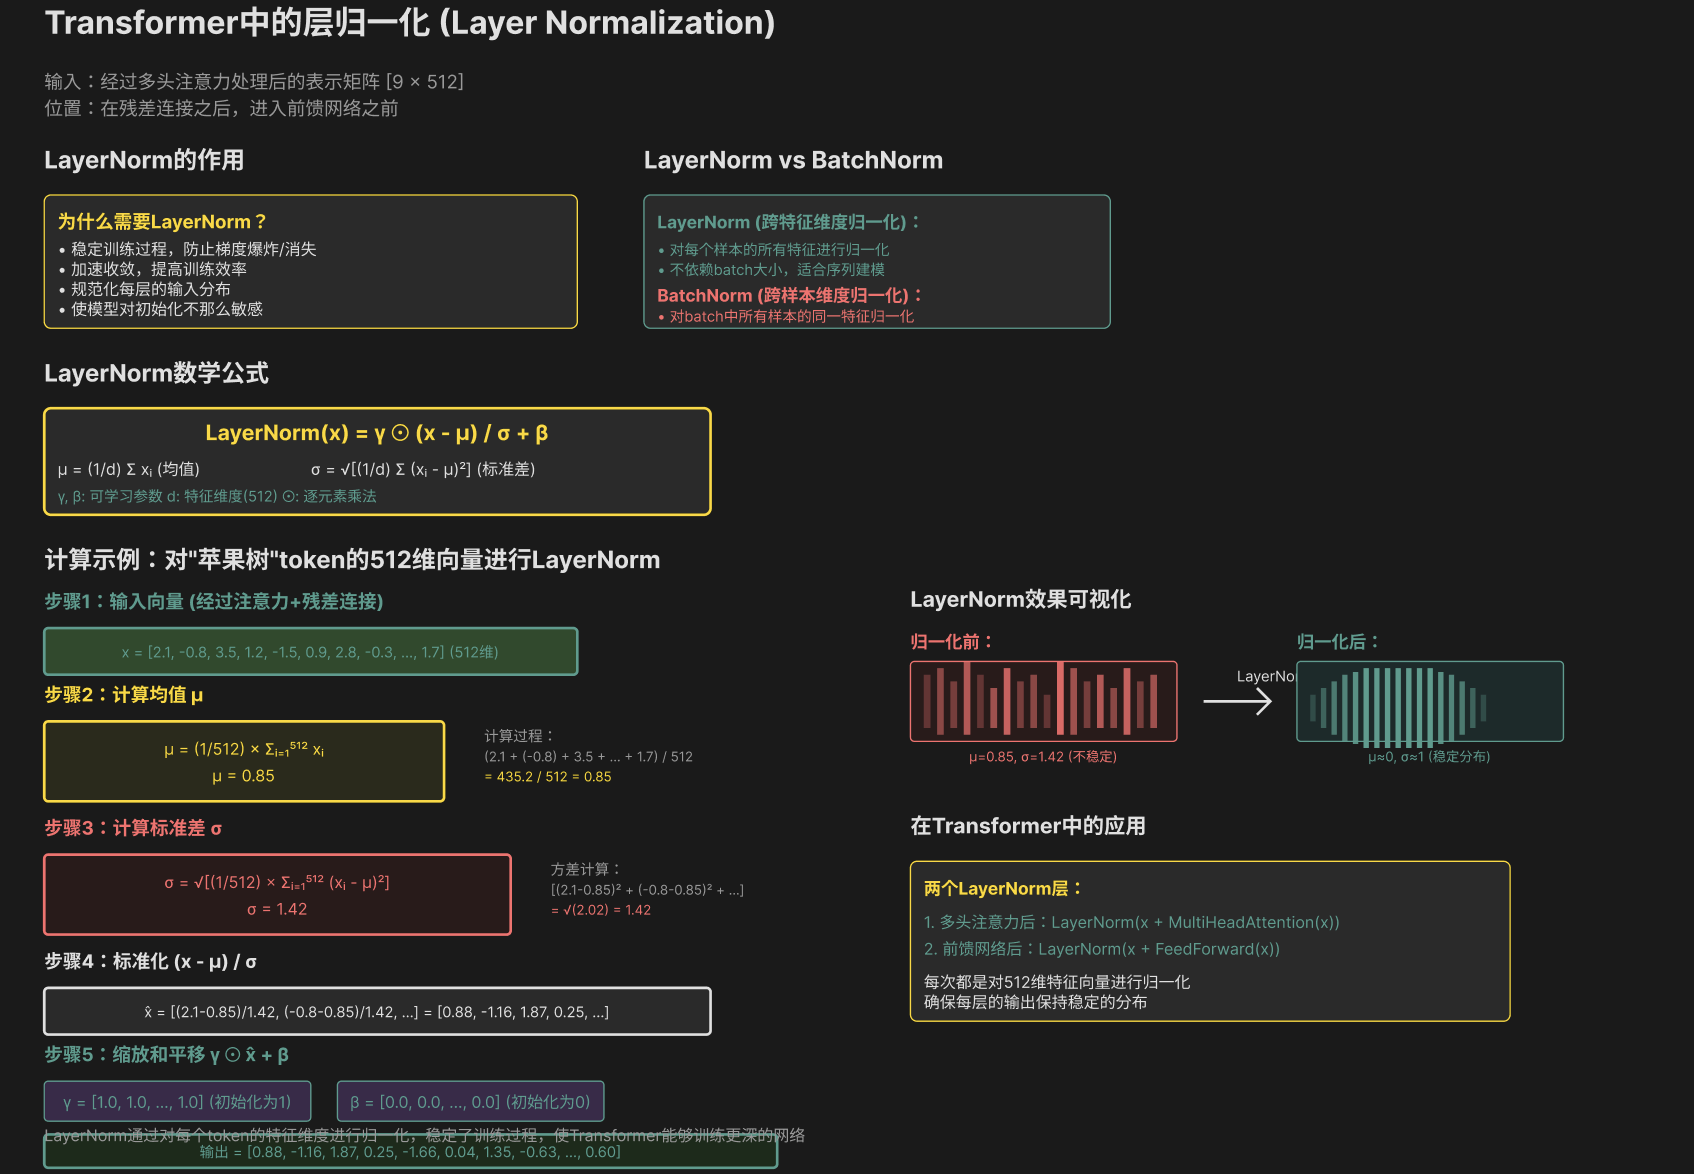

### 残差连接

### 目前为止，AI领域引用最高的论文登场

https://arxiv.org/pdf/1512.03385

### 我们发现随着神经网络的加深，效果不增长反而会下降了

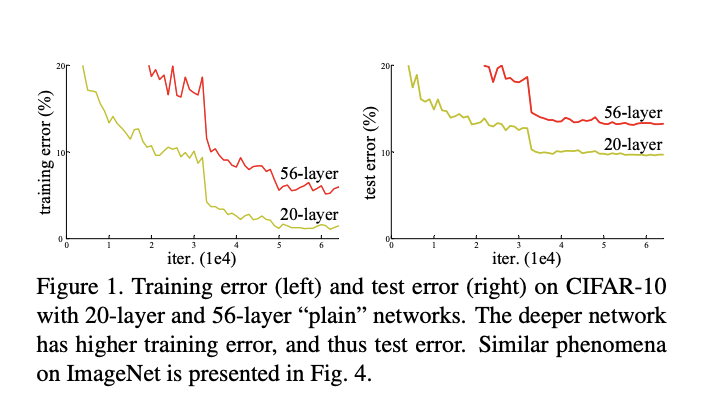

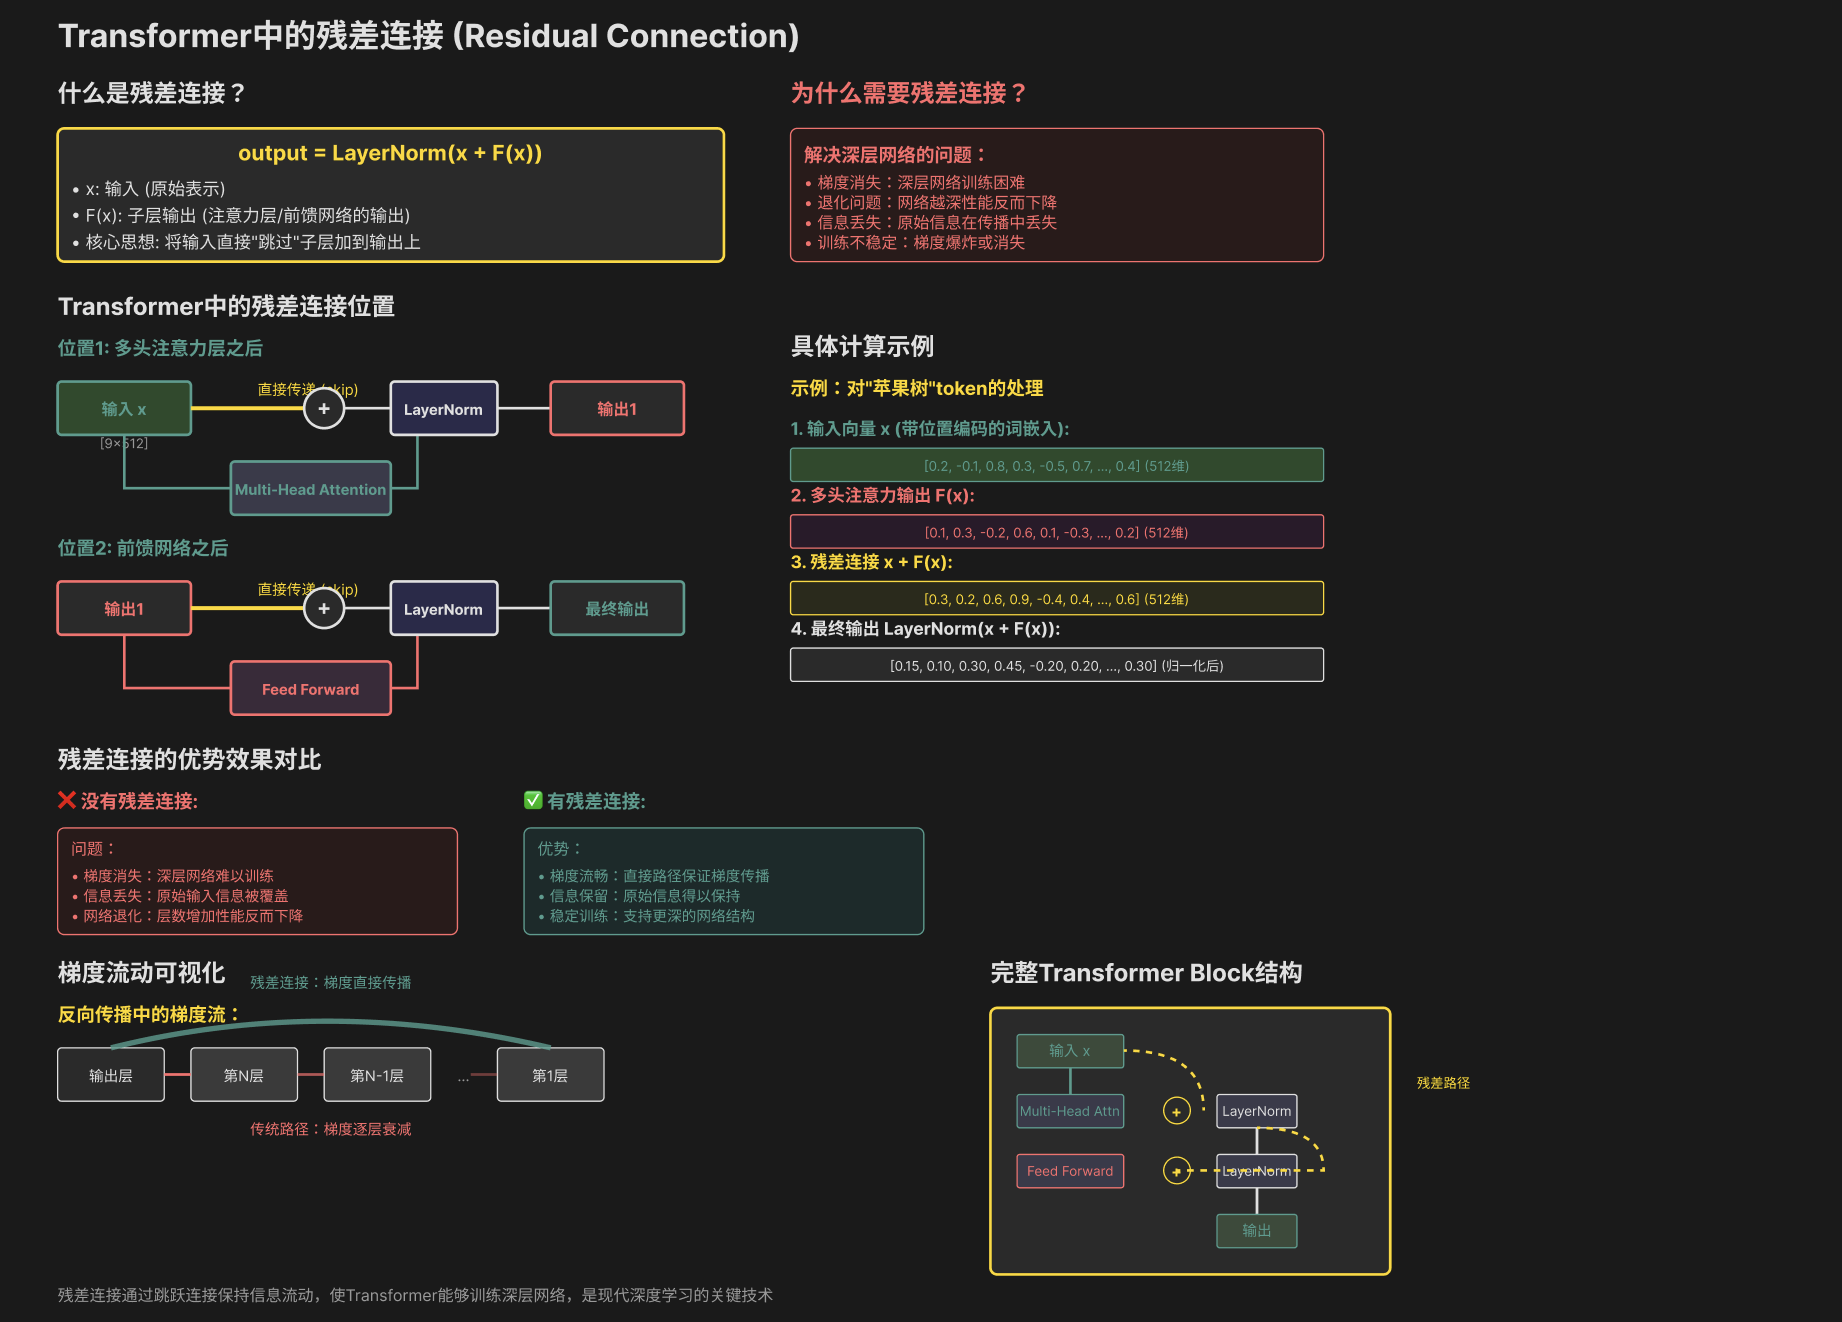

* **原版 Transformer（Vaswani et al., 2017）把 LayerNorm 放在残差“之后”（Post-LN）：**
  $y=\text{LN}(x+F(x))$。
* **后来更常见的做法是放在残差“之前”（Pre-LN）：**
  $y=x+F(\text{LN}(x))$。
* 两种摆放都能工作，但在收敛速度、训练稳定性和深层网络表现上有不同的权衡。

---

## 两种摆放方式

|          | Post-LN（残差后）                  | Pre-LN（残差前）                      |
| -------- | ----------------------------- | -------------------------------- |
| 公式       | $y=\text{LN}(x+F(x))$         | $y=x+F(\text{LN}(x))$            |
| **优点**   | 输出始终归一化；直观“Add & Norm”        | 梯度直接沿残差流动→更深层仍稳定；不太依赖学习率 warm-up |
| **缺点**   | 深层时梯度易爆/消；常需小学习率+长 warm-up    | 层输出未归一化→可能数值漂移，通常在最后再加一次 LN      |
| **实际使用** | 原论文 Transformer-base、早期机器翻译模型 | BERT、GPT-2/3、CLIP、T5、最新大模型       |

---

## 为什么 Pre-LN 更易训练？

1. **梯度不再穿过 LN**
   残差直接把 $x$ 传到底，梯度在深网里更“顺畅”，减轻梯度消失/爆炸。
2. **学习率 warm-up 可极短或省掉**
   Xiong et al.（2020）实验证明 Pre-LN 在大学习率下也稳定 ([arXiv][2])。
3. **深层可扩展**
   24-48 层甚至上百层的预训练语言模型大多采用 Pre-LN。


### 2.2.3 FFN & 残差连接

### 如果全是线性变换，那不是等于就只✖️了一个矩阵吗

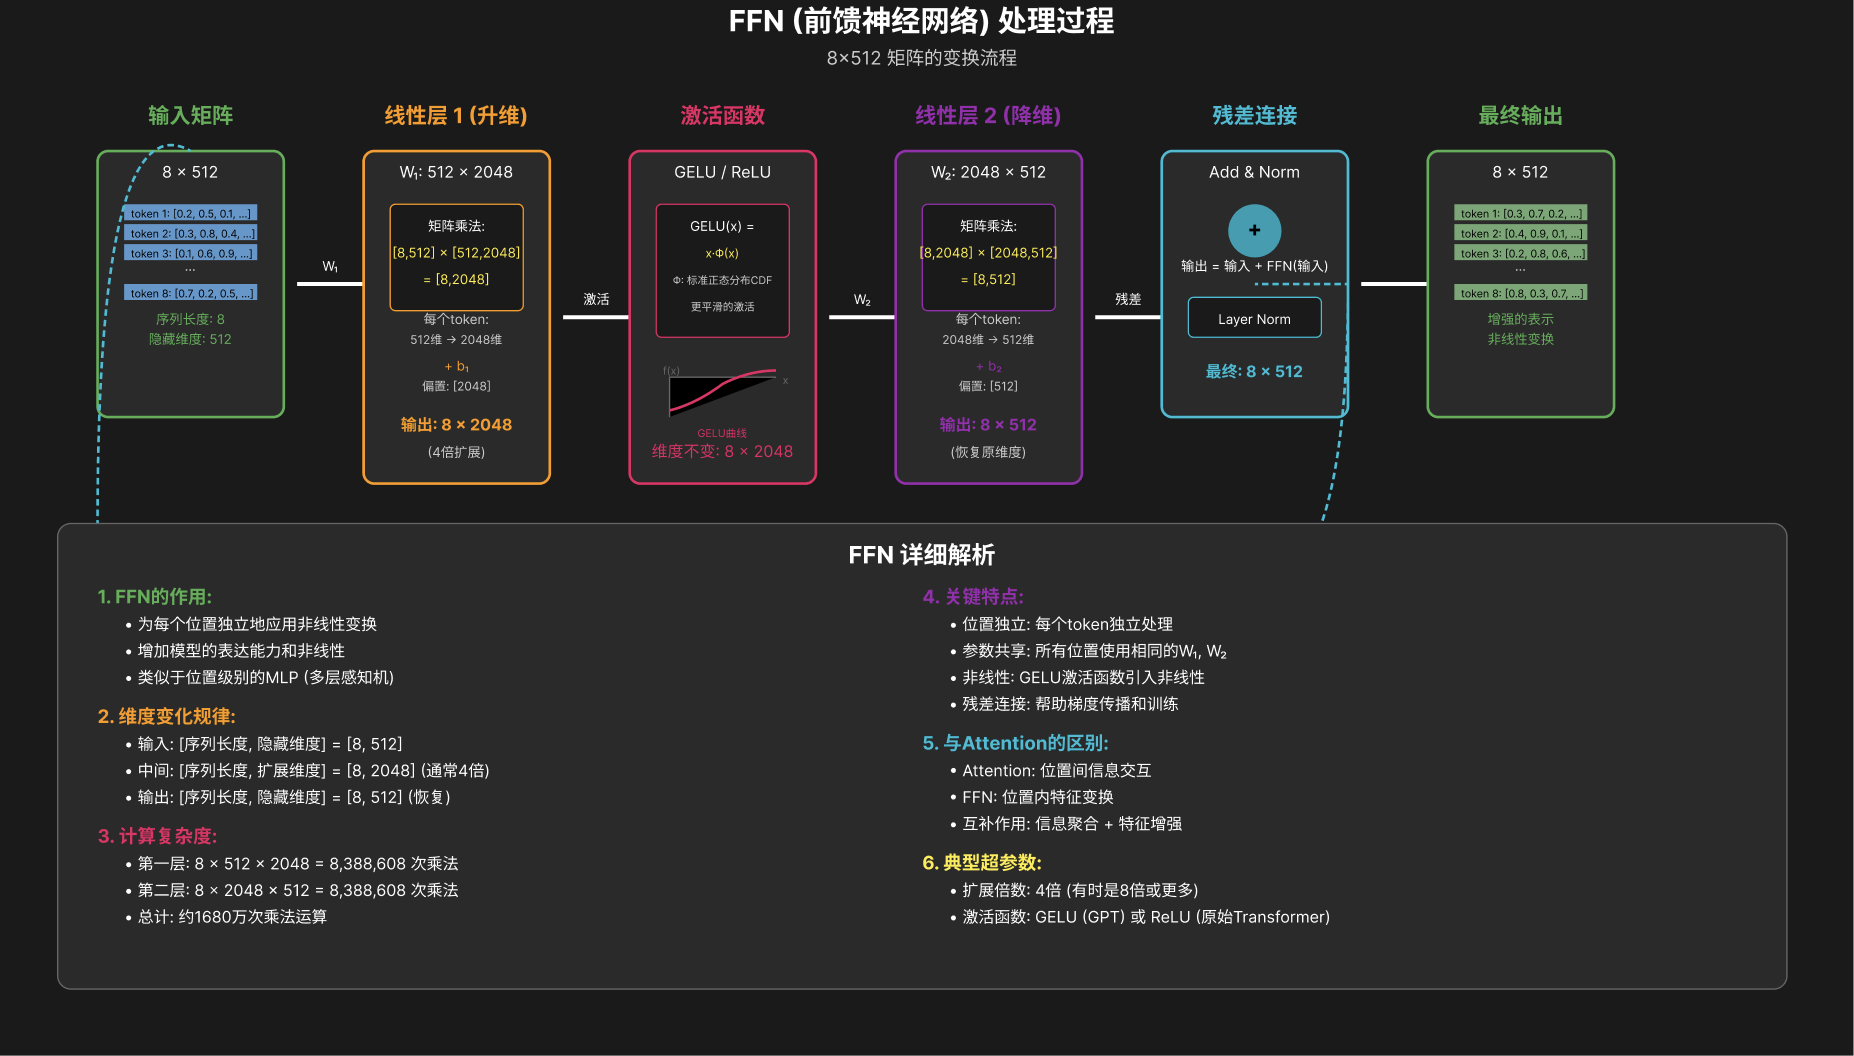

### 2.2.4 堆叠多层

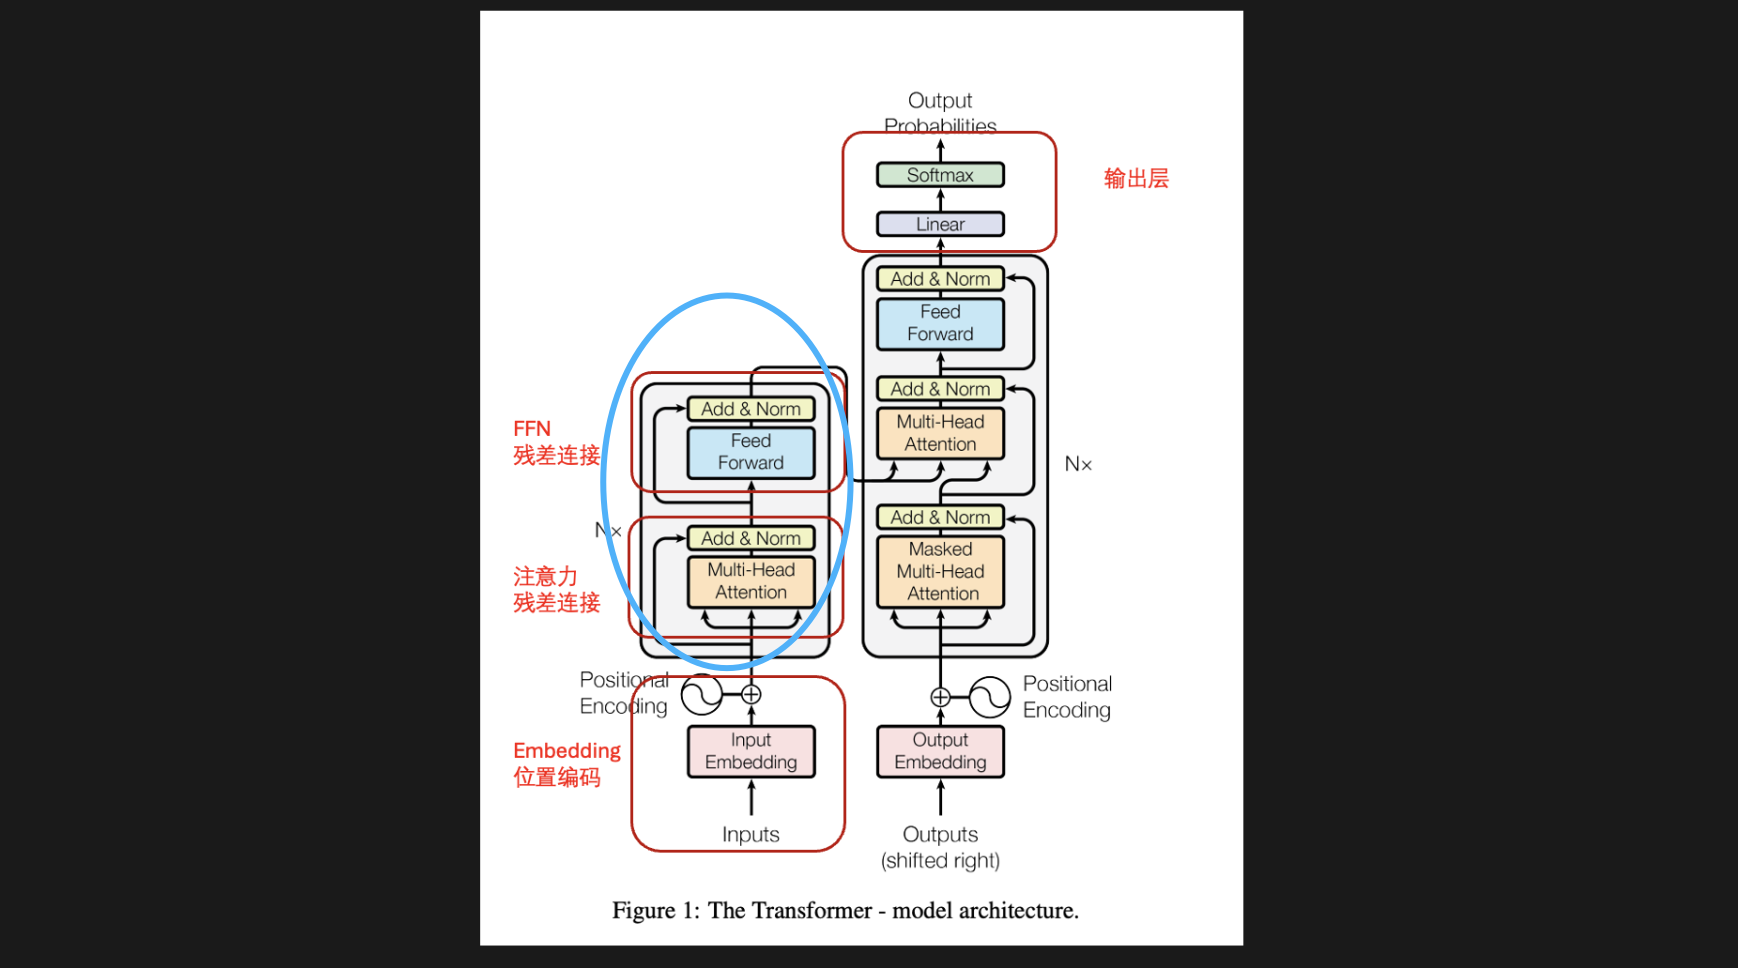

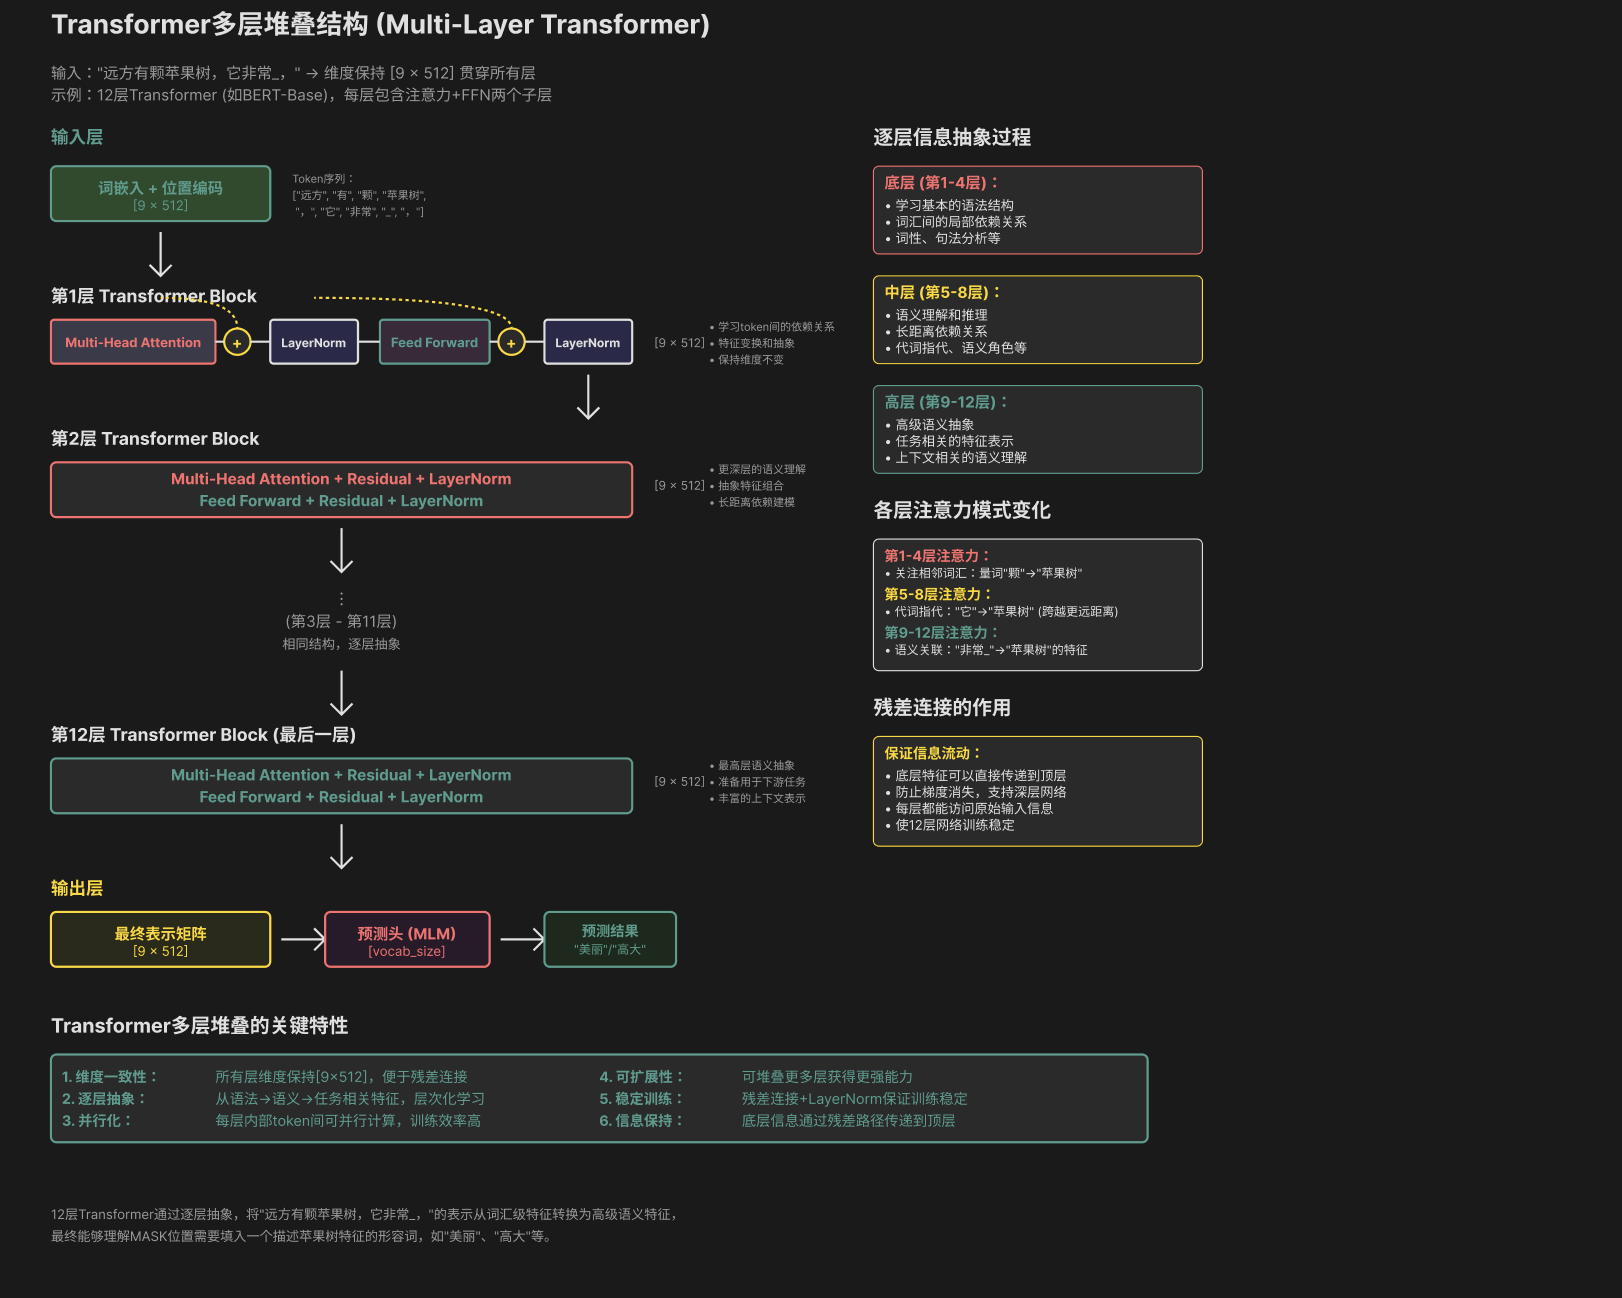

# 3 Encoder、Encoder-Decoder 拓展 1）Encode架构和Bert 2）Encoder-Decoder和T5

## 3.1 Decoder only（GPT，QWEN，LLAMA）

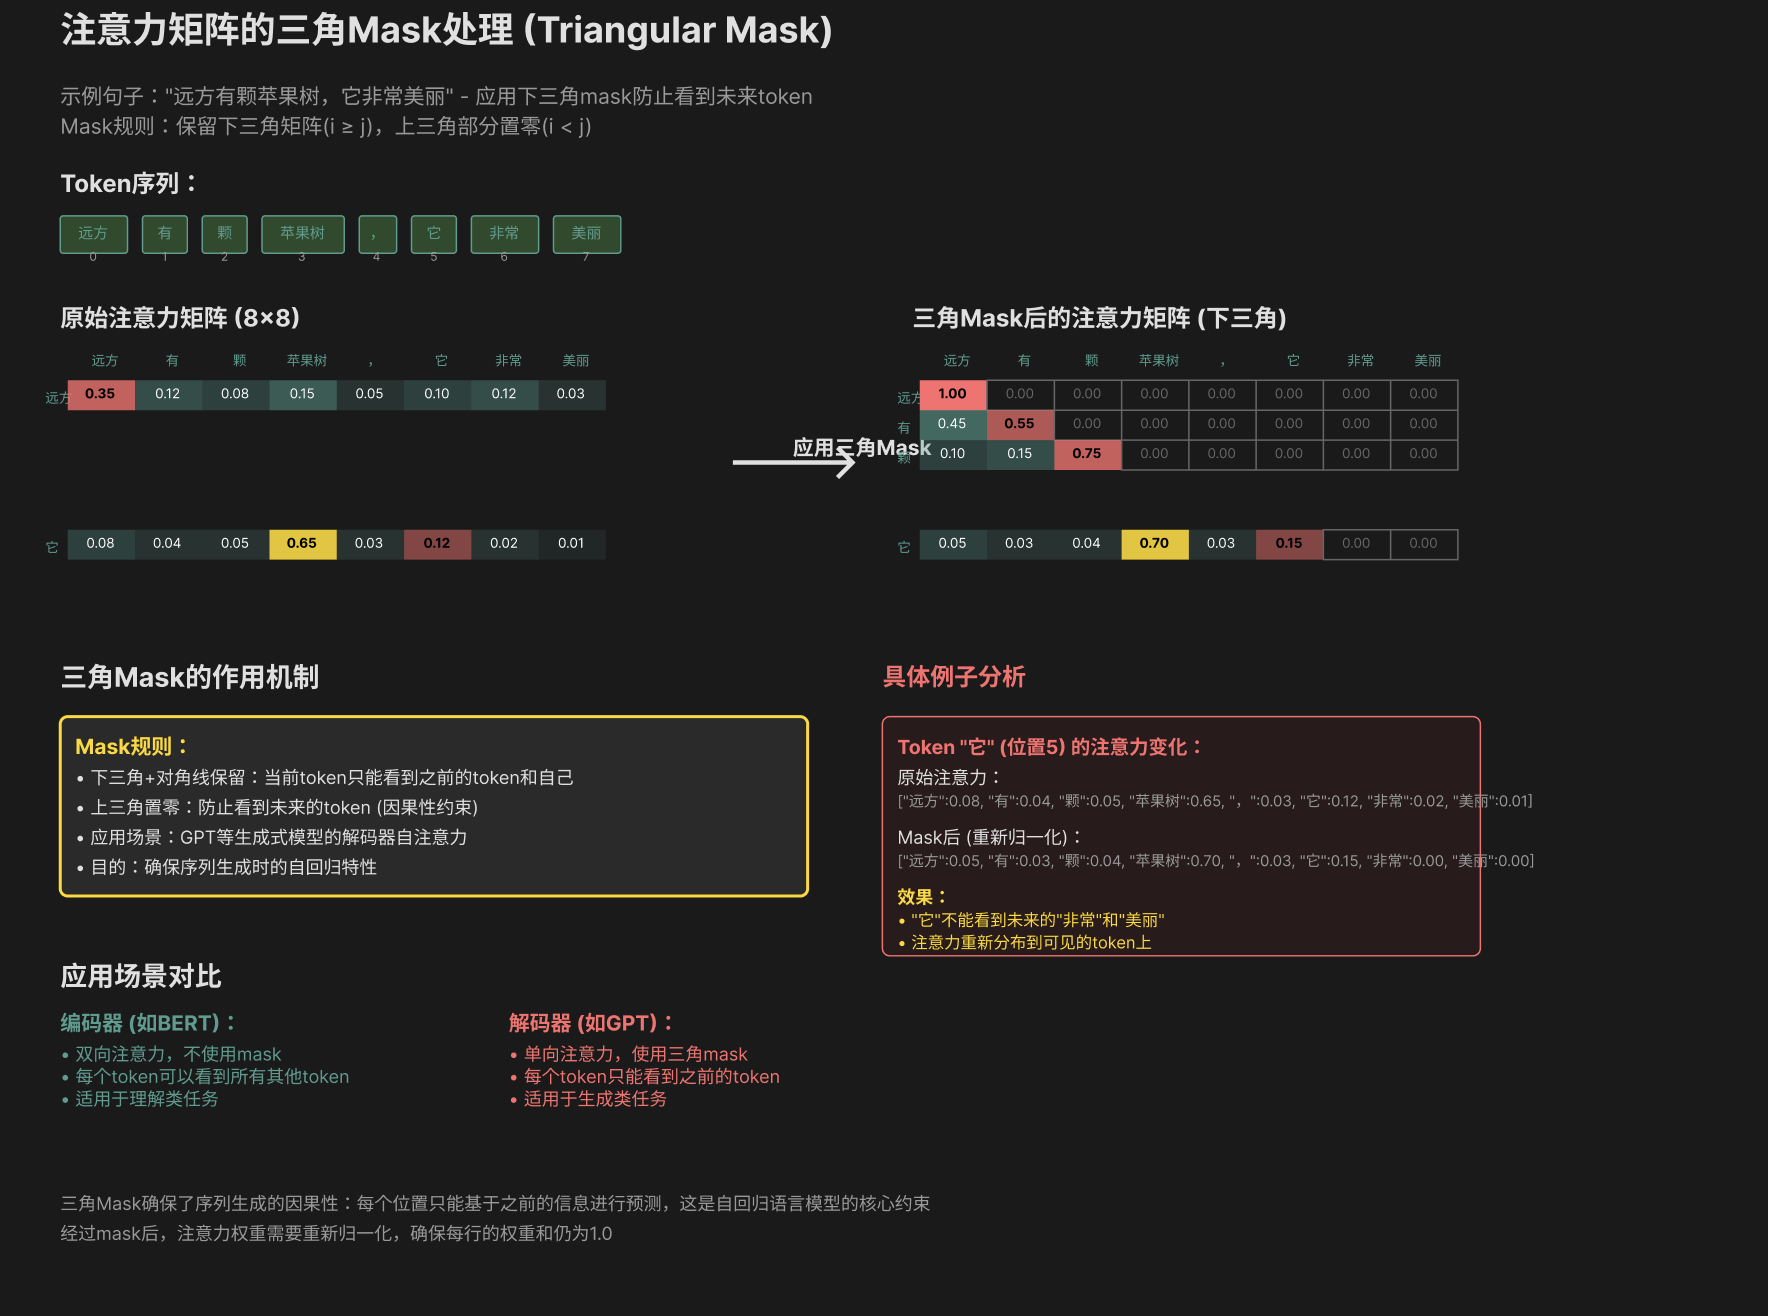

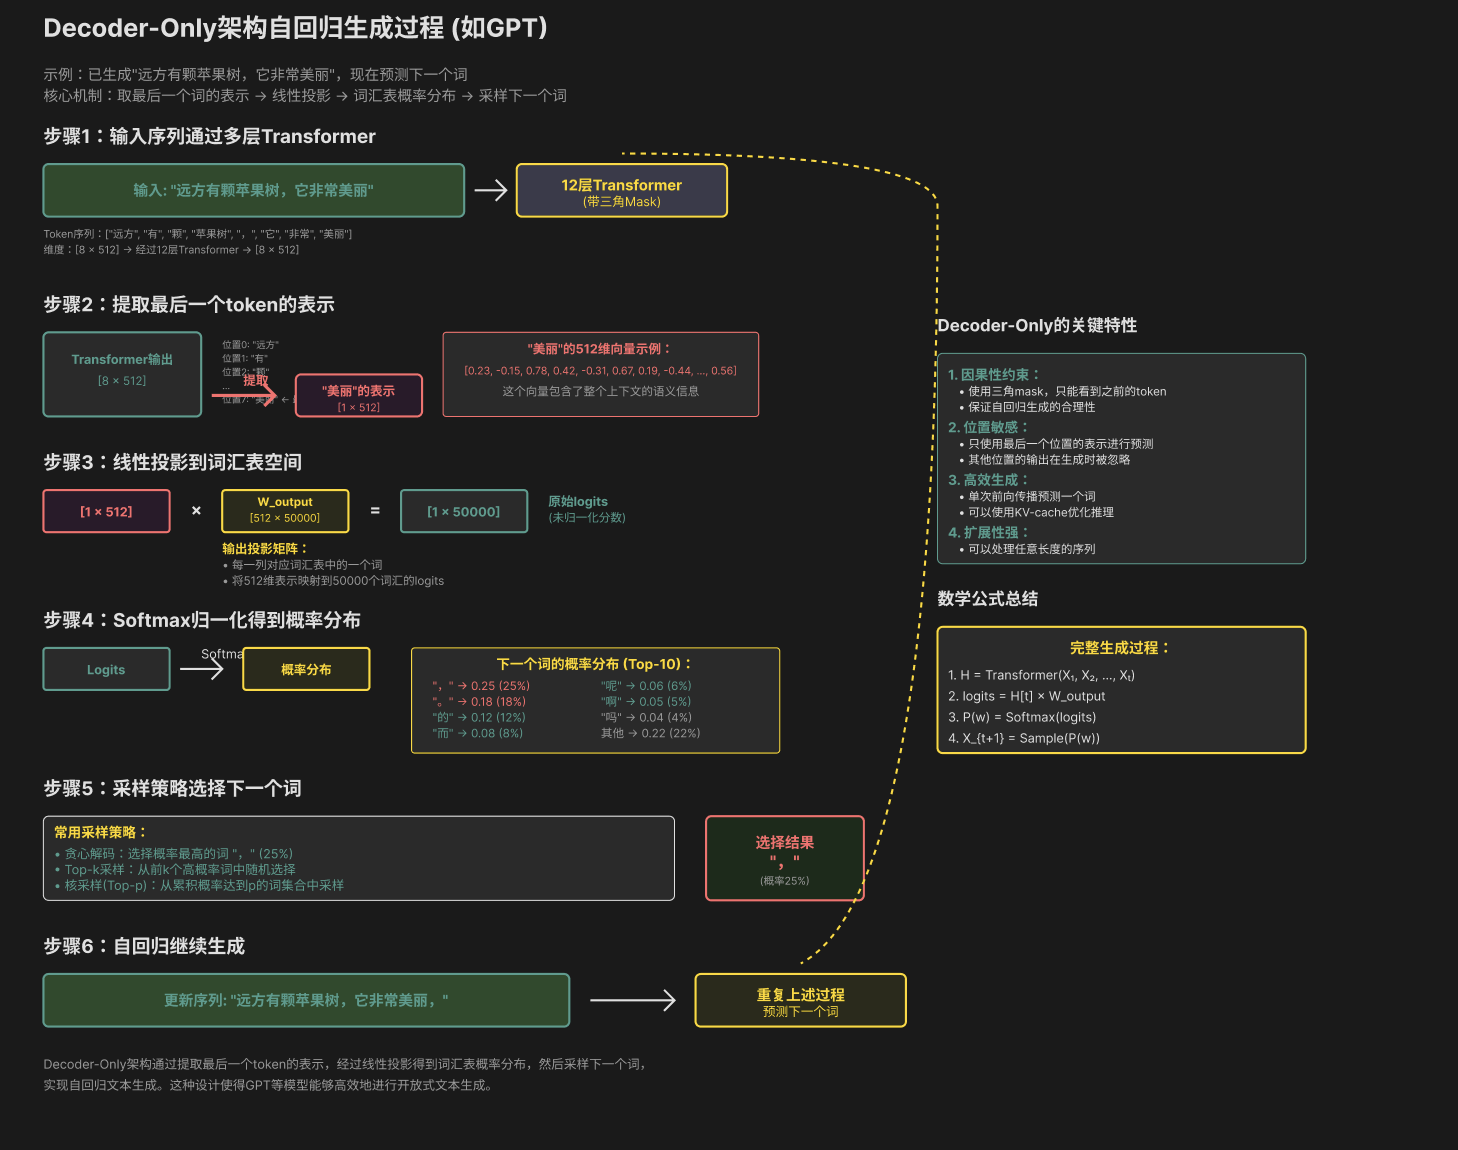

## 3.2 Encode only（Bert）

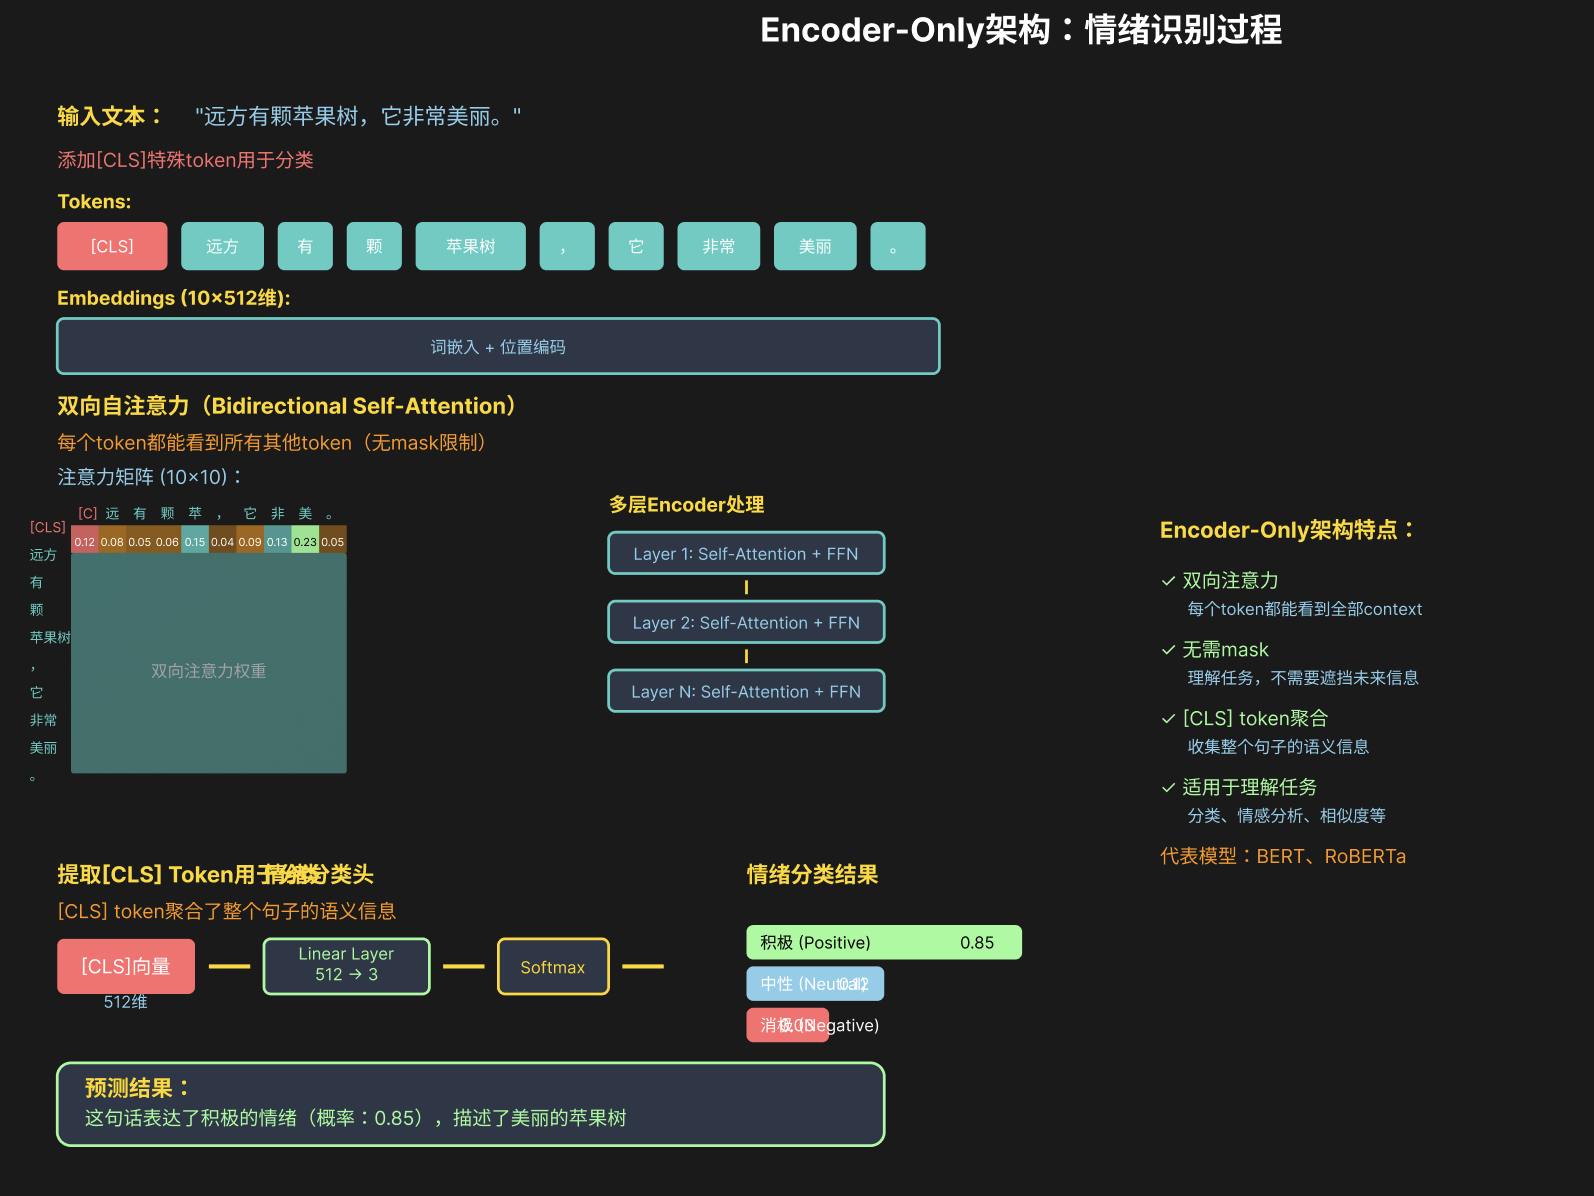

**关键特点：**
- 双向注意力：每个token都能看到句子中的所有其他token，无需mask
- [CLS] token：用于聚合整个句子的语义信息
- 分类头：将[CLS]向量映射到情绪类别
- 适用场景：文本分类、情感分析、语义理解等任务
- **与Decoder-Only的区别：**
- Decoder-Only用于生成，需要三角mask防止看到未来
- Encoder-Only用于理解，可以看到全部context
- Decoder-Only逐个生成token，Encoder-Only一次性处理整个序列

## 3.3 Encode-Decode （T5）

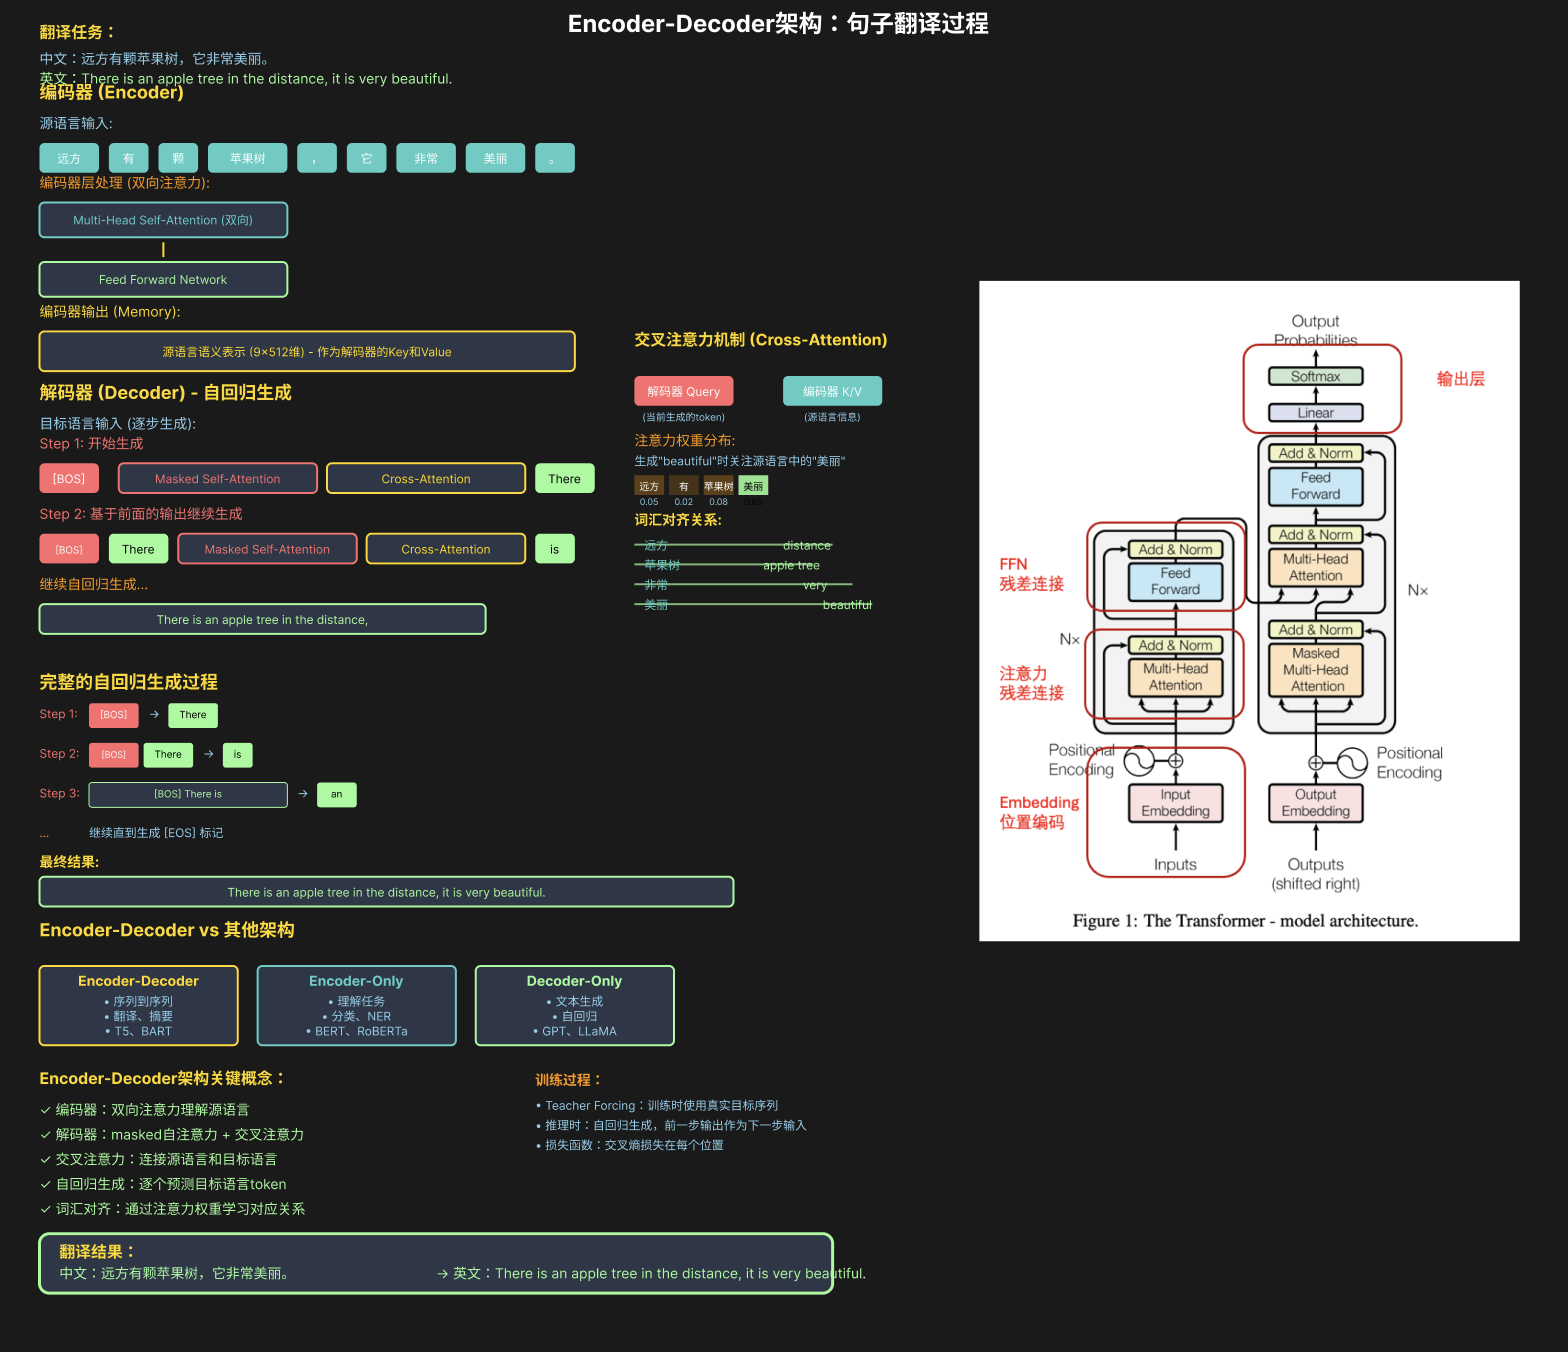

## 核心组件

### 编码器 (Encoder)

* 使用双向自注意力理解源语言
* 输出作为解码器的 **Key** 和 **Value**

### 解码器 (Decoder)

* **Masked** 自注意力：防止看到未来 token
* 交叉注意力：关注源语言相关信息
* 自回归生成：逐步生成目标语言

### 交叉注意力机制

* **Query** 来自解码器当前状态
* **Key** 和 **Value** 来自编码器输出
* 学习源语言与目标语言的对齐关系

---

## 生成过程

1. 从 **\[BOS]** 开始，每次生成一个 token
2. 当前生成的 token 会作为下一步的输入
3. 通过交叉注意力关注源语言的相关部分
4. 直到生成 **\[EOS]** 结束标记

> 这种架构特别适合序列到序列任务，如机器翻译、文本摘要等。


# 4. 为什么transformer架构好

（1）并行效率快 （2）深入理解词与词之间的关系 （3）架构通用（跨模态，标准化） 

结合文档理解GQA，MHA，MLA的概念

# 5.MOE

## 5.1 基础版MOE

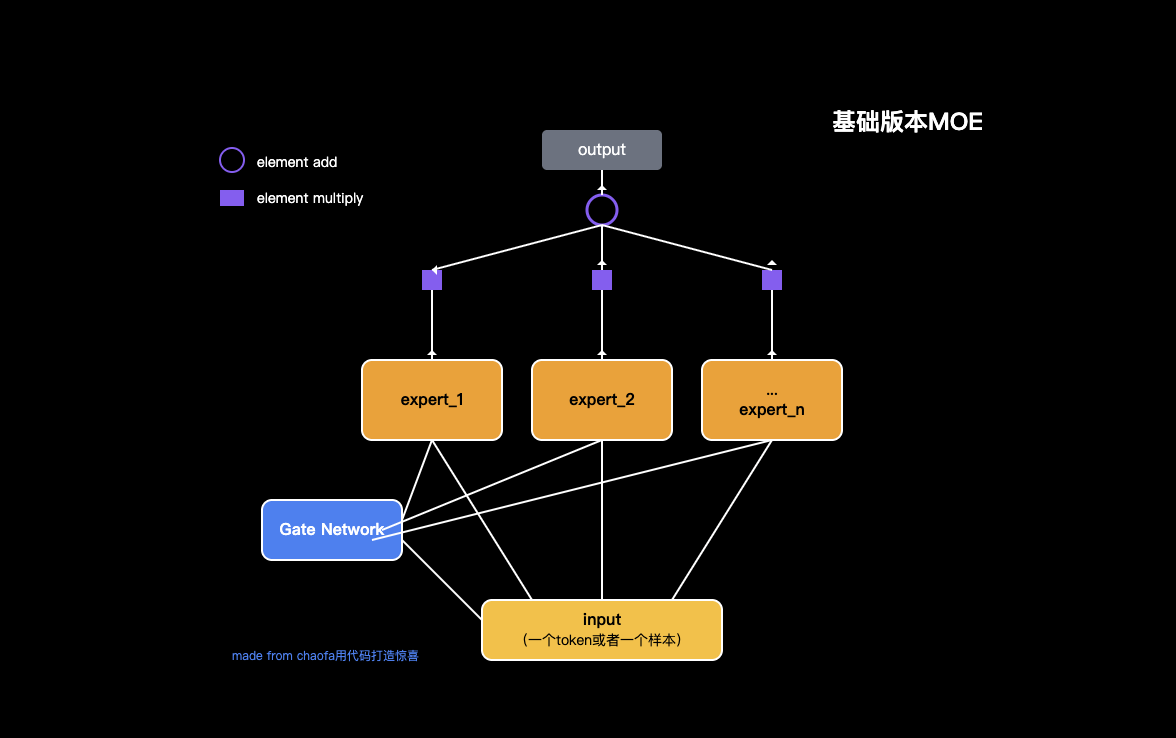

In [69]:
import torch
import torch.nn as nn

class BasicExpert(nn.Module):
    # 一个 Expert 可以是一个最简单的， linear 层即可
    # 也可以是 MLP 层
    # 也可以是 更复杂的 MLP 层（active function 设置为 swiglu）
    def __init__(self, feature_in, feature_out):
        super().__init__()
        self.linear = nn.Linear(feature_in, feature_out)
    
    def forward(self, x):
        return self.linear(x)

In [71]:
class BasicMOE(nn.Module):
    def __init__(self, feature_in, feature_out, expert_number):
        super().__init__()
        self.experts = nn.ModuleList(
            [
                BasicExpert(feature_in, feature_out) for _ in range(expert_number)
            ]
        )
        # gate 就是选一个 expert 
        self.gate = nn.Linear(feature_in, expert_number)
    
    def forward(self, x):
        # x 的 shape 是 （batch, feature_in)
        expert_weight = self.gate(x)  # shape 是 (batch, expert_number)
        expert_out_list = [
            expert(x).unsqueeze(1) for expert in self.experts
        ]  # 里面每一个元素的 shape 是： (batch, ) ??

        # concat 起来 (batch, expert_number, feature_out)
        expert_output = torch.cat(expert_out_list, dim=1)

        # print(expert_output.size())

        expert_weight = expert_weight.unsqueeze(1) # (batch, 1, expert_nuber)

        # expert_weight * expert_out_list
        output = expert_weight @ expert_output  # (batch, 1, feature_out)
        
        return output.squeeze()


def test_basic_moe():
    x = torch.rand(2, 4)

    basic_moe = BasicMOE(4, 3, 2)
    out = basic_moe(x)
    print(out)


test_basic_moe()

tensor([[-0.3282,  0.3064,  0.0731],
        [-0.0784,  0.0734, -0.0345]], grad_fn=<SqueezeBackward0>)


## 5.2 SparseMoE （大模型训练使用）

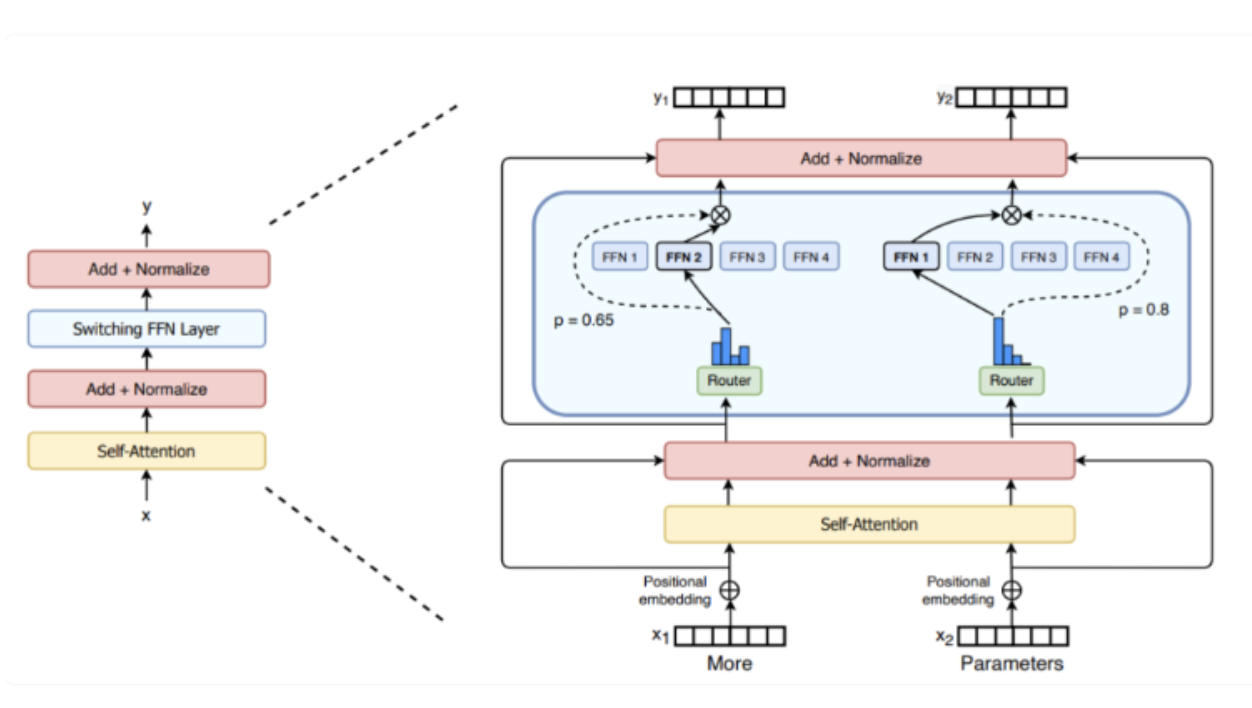

In [ ]:
import torch.nn.functional as F
# 主要参考自 mistral MOE 的实现

class MOERouter(nn.Module):
    def __init__(self, hidden_dim, expert_number, top_k):
        super().__init__()
        self.gate = nn.Linear(hidden_dim, expert_number)
        self.expert_number = expert_number
        self.top_k = top_k
    
    def forward(self, hidden_states):
        # 计算路由logits
        router_logits = self.gate(hidden_states)  # shape is (b * s, expert_number)
        
        # 计算专家经过softmax之后的概率
        routing_probs = F.softmax(router_logits, dim=-1, dtype=torch.float)
        
        # 计算topk的专家的输出
        router_weights, selected_experts = torch.topk(
            routing_probs, self.top_k, dim=-1
        )  # shape都是 (b * s, top_k)
        
        # 专家权重归一化
        router_weights = router_weights / router_weights.sum(dim=-1, keepdim=True)
        router_weights = router_weights.to(hidden_states.dtype)
        
        # 生成专家掩码
        expert_mask = F.one_hot(
            selected_experts,
            num_classes=self.expert_number
        )  # shape是 (b * s, top_k, expert_number)
        expert_mask = expert_mask.permute(2, 1, 0)  # (expert_number, top_k, b * s)
        
        return router_logits, router_weights, selected_experts, expert_mask


class MOEConfig:
    def __init__(
            self, 
            hidden_dim, 
            expert_number, 
            top_k, 
            shared_experts_number=2,
        ):
        self.hidden_dim = hidden_dim
        self.expert_number = expert_number
        self.top_k = top_k
        self.shared_experts_number = shared_experts_number

class SparseMOE(nn.Module):
    # 稀疏 MOE 模型，这里每一个 token 都会过 topk 个专家，得到对应token 的 hidden_embeddings
    def __init__(self, config):
        super().__init__()

        self.hidden_dim = config.hidden_dim

        self.expert_number = config.expert_number
        self.top_k = config.top_k

        self.experts = nn.ModuleList(
            [
                BasicExpert(self.hidden_dim, self.hidden_dim) for _ in range(self.expert_number)
            ]
        )

        self.router = MOERouter(self.hidden_dim, self.expert_number, self.top_k)
    
    def forward(self, x):
        # x shape is (b, s, hidden_dim)
        batch_size, seq_len, hidden_dim = x.size()

        # 合并前两个维度，因为不是 Sample 维度了，而是 token 维度
        hidden_states = x.view(-1, hidden_dim) # shape is(b * s, hidden_dim)

        router_logits, router_weights, selected_experts_indices, expert_mask = self.router(hidden_states)
        # 其中 selected_experts_indices shape 是 (b * s, top_k)
        # 其中 expert_mask shape 是 (expert_number, top_k, b * s)
        
        final_hidden_states = torch.zeros(
            (batch_size * seq_len, hidden_dim),
            dtype=hidden_states.dtype,
            device=hidden_states.device
        )

        for expert_idx in range(self.expert_number):
            expert_layer = self.experts[expert_idx]
            # expert_mask[expert_idx] shape 是 (top_k, b * s)
            idx, top_x = torch.where(expert_mask[expert_idx]) 
            # idx 和 top_x 都是一维 tensor
            # idx 的值是 0 或 1, 表示这个 token 是作为当前专家的 top1 还是 top2
            # top_x 的值是 token 在 batch*seq_len 中的位置索引
            # 例如对于 batch_size=2, seq_len=4 的输入:
            # top_x 的值范围是 0-7, 表示在展平后的 8 个 token 中的位置
            # idx 的值是 0/1, 表示这个 token 把当前专家作为其 top1/top2 专家

            # hidden_states 的 shape 是 (b * s, hidden_dim)
            # 需要取到 top_x 对应的 hidden_states
            current_state = hidden_states.unsqueeze(
                0
            )[:, top_x, :].reshape(-1, hidden_dim) # （selected_token_number, hidden_dim）

            # router_weight 的 shape 是 (b * s, top_k)
            current_hidden_states = expert_layer(
                current_state
            ) * router_weights[top_x, idx].unsqueeze(-1)  # （selected_token_number, 1） 这里有广播

            # 把当前专家的输出加到 final_hidden_states 中
            # 方式1 的写法性能更好，并且方式1容易出现
            final_hidden_states.index_add_(0, top_x, current_hidden_states.to(hidden_states.dtype))
            # 方式2
            # final_hidden_states[top_x] += current_hidden_states.to(hidden_states.dtype)
            # 方式1 的写法性能更差，并且方式1容易出现错误，+= 操作在处理重复索引时需要多次读写内存，可能会导致竞争条件

        # 把 final_hidden_states 还原到原来的 shape
        final_hidden_states = final_hidden_states.reshape(batch_size, seq_len, hidden_dim)

        return final_hidden_states, router_logits # shape 是 (b * s, expert_number)


def test_token_level_moe():
    x = torch.rand(2, 4, 16)
    config = MOEConfig(16, 2, 2)
    token_level_moe = SparseMOE(config)
    out = token_level_moe(x)
    print(out[0].shape, out[1].shape)


test_token_level_moe()

## 5.3 ShareExpert SparseMoE （deepseek 版本）

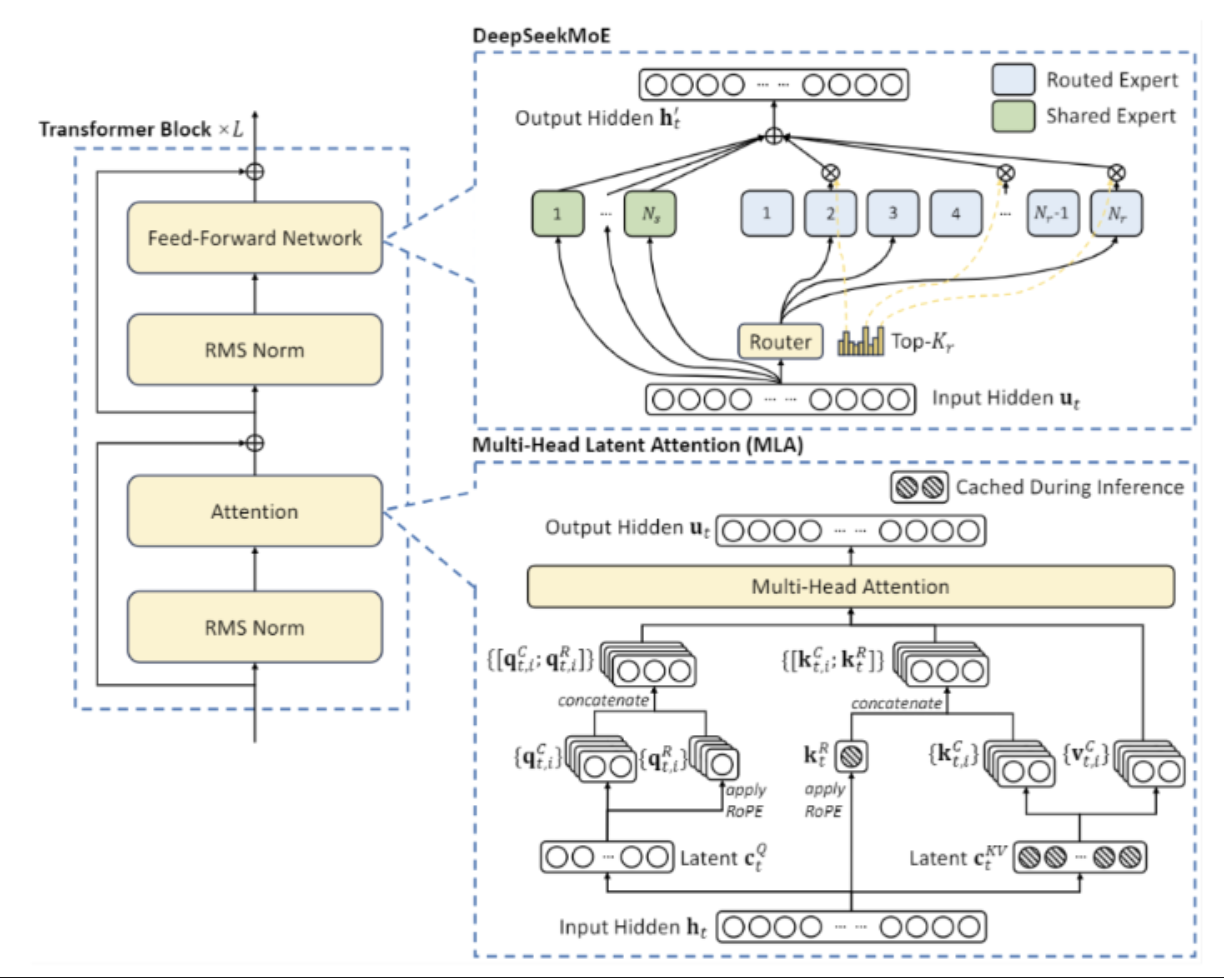

In [86]:
class ShareExpertMOE(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.moe_model = SparseMOE(config)
        self.shared_experts = nn.ModuleList(
            [
                BasicExpert(
                    config.hidden_dim, config.hidden_dim
                ) for _ in range(config.shared_experts_number)
            ]
        )

    def forward(self, x):
        # x shape 是 (b, s, hidden_dim)
        # 首先过 moe 模型
        sparse_moe_out, router_logits = self.moe_model(x)
        
        # 针对的还是 x 的每一个 
        # 然后过 shared experts
        shared_experts_out = [
            expert(x) for expert in self.shared_experts
        ] # 每一个 expert 的输出 shape 是 (b, s, hidden_dim)
        
        shared_experts_out = torch.stack(
            shared_experts_out, dim=0
        ).sum(dim=0)
        
        # 把 sparse_moe_out 和 shared_experts_out 加起来
        return sparse_moe_out + shared_experts_out, router_logits


def test_share_expert_moe():
    x = torch.rand(2, 4, 16)
    config = MOEConfig(16, 2, 2)
    share_expert_moe = ShareExpertMOE(config)
    out = share_expert_moe(x)
    print(out[0].shape, out[1].shape)


test_share_expert_moe()

torch.Size([2, 4, 16]) torch.Size([8, 2])
